# OEP auxiliary basis optimization — analysis notebook

This notebook orchestrates and analyzes *oep-opt-package* runs (Slurm submission, parsing `run.log`, collecting metrics with/without radial cutoff, and visual diagnostics of potentials/density differences).

## How to use (recommended workflow)
1. Set **ROOT / workdir paths** in the *Experiment* section.
2. Run **Utilities** once (function definitions).
3. Run **Sweep / aggregation** to build `df`, then use the **Summary / plots** section.

## Reproducibility checklist
- Paths: avoid hard-coded `/home/...` where possible; prefer `ROOT = Path(...).resolve()`.
- Execution: *Kernel → Restart & Run All* should succeed without manual edits.
- Outputs: keep large artifacts (plots, tables) saved to disk; display compact summaries in-notebook.


In [1]:
import argparse, os, re, sys, json, shutil, subprocess, time
from pathlib import Path
from typing import List, Tuple, Optional, Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import Markdown, display

from IPython.display import display, HTML

def display_report_collapsible(md_text: str, title="Report"):
    html = f"""
    <details>
      <summary style="font-size:16px; font-weight:600;">{title}</summary>
      <pre style="white-space:pre-wrap;">{md_text}</pre>
    </details>
    """
    display(HTML(html))

In [2]:
# Display/plot defaults (tune as needed)
import pandas as pd
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


## Slurm Submit and wait


In [3]:
def submit_slurm_and_wait_old(workdir: Path, sbatch_cmd: str = "sbatch", poll_s: int = 40, max_wait_s: int = 0,
                                 sentinel="Molpro calculation terminated", server = "tcsv020") -> Tuple[int, str]:
    workdir.mkdir(parents=True, exist_ok=True)
    marker = workdir / "_submitted"
    out_file = workdir / "output"
    err_file = workdir / "error"
    csv_file = workdir / "rho_ks-total-final-z.csv"
    if csv_file.exists():
        print(f"[INFO] Found existing {csv_file}, skipping SLURM submission.")
        return
    print(f"Workdir is : {workdir}")
    if server == "tcsv020":
        proc = subprocess.run(sbatch_cmd.split() + ["run.sh"], cwd=str(workdir))
    else:
        proc = proc = subprocess.run(["ssh", "tcsv020", f"cd {workdir} && {sbatch_cmd} run.sh"])

    print(f"[INFO] Job submitted : {workdir} now waiting...")
    sb_out = (proc.stdout or "") + "\n" + (proc.stderr or "")
    m = re.search(r"Submitted batch job\s+(\d+)", sb_out) or re.search(r"(\d+)", sb_out)
    job_id = m.group(1) if m else "UNKNOWN"
    marker.write_text(str(job_id))

    start = time.time()
    while True:
        if out_file.exists():
            try:
                txt = out_file.read_text(errors="ignore")
                if sentinel in txt:
                    time.sleep(5)
                    break
            except Exception:
                pass
        if job_id != "UNKNOWN":
            q = subprocess.run(["squeue", "-j", str(job_id), "-h"],
                               cwd=str(workdir), capture_output=True, text=True)
            if q.returncode == 0 and q.stdout.strip() == "":
                time.sleep(5)
                break
        if max_wait_s > 0 and (time.time() - start) > max_wait_s:
            return (998, f"TIMEOUT_WAITING_FOR_SLURM (job {job_id})")
        time.sleep(poll_s)

    out_text = ""
    end_wait_start = time.time()
    dnorm_pat = re.compile(r"(?im)^\s*SYMMETRIZED\s+([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][+-]?\d+)?)")
    while (time.time() - end_wait_start) < 60:
        try: out_text = out_file.read_text(errors="ignore") if out_file.exists() else ""
        except Exception: out_text = ""
        if out_text and ("Molpro calculation terminated" in out_text or dnorm_pat.search(out_text)):
            #print(f"[INFO] Job : {workdir} Finished.")
            break
        time.sleep(2)

    try:
        out_text += "\n" + (err_file.read_text(errors="ignore") if err_file.exists() else "")
    except Exception:
        pass

    rc = 0
    if "ERROR" in out_text and "WARNING" not in out_text: rc = 1
    if "Molpro calculation terminated" not in out_text: rc = max(rc, 1)
    return 


In [4]:
import os, time, re, shlex, subprocess
from pathlib import Path
from typing import Tuple

def submit_slurm_and_wait(
    workdir: Path,
    sbatch_cmd: str = "sbatch",
    poll_s: int = 40,
    max_wait_s: int = 0,
    sentinel: str = "Molpro calculation terminated",
    server: str = "tcsv020",   # if you are already on tcsv020, this still works
    redo: str = "no",
) -> Tuple[int, str]:
    workdir = Path(workdir).resolve()
    workdir.mkdir(parents=True, exist_ok=True)

    marker   = workdir / "_submitted"
    out_file = workdir / "output"
    err_file = workdir / "error"
    csv_file = workdir / "rho_ks-total-final-z.csv"

    if csv_file.exists():
        if redo == "no":     #print(f"[INFO] Found existing {csv_file}, skipping SLURM submission.")
            return (0, "SKIPPED_ALREADY_DONE")

    print(f"Workdir is : {workdir}")
    run_file = Path("/home/mandalia/WORK_DIR/run.sh").resolve()
    try:
        os.link(run_file, workdir / "run.sh")
    except OSError:
        shutil.copy2(run_file, workdir / "run.sh")
    # --- Submit job (local sbatch if server == 'tcsv020', else via SSH) ---
    if server == "tcsv020":
        proc = subprocess.run(
            sbatch_cmd.split() + ["run.sh"],
            cwd=str(workdir),
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            universal_newlines=True,
            check=False,
        )
    else:
        # Submit on remote submit host (shared FS assumed)
        remote_cmd = f"cd {shlex.quote(str(workdir))} && {sbatch_cmd} run.sh"
        proc = subprocess.run(
            ["ssh", server, remote_cmd],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            universal_newlines=True,
            check=False,
        )

    sb_out = (proc.stdout or "") + "\n" + (proc.stderr or "")
    if proc.returncode != 0:
        return (proc.returncode, f"SUBMIT_FAILED:\n{sb_out.strip()}")

    print(f"[INFO] Job submitted : {workdir} now waiting...")

    # Extract job id (best-effort)
    m = re.search(r"Submitted batch job\s+(\d+)", sb_out) or re.search(r"\b(\d{6,})\b", sb_out)
    job_id = m.group(1) if m else "UNKNOWN"
    try:
        marker.write_text(str(job_id))
    except Exception:
        pass

    # --- Wait loop ---
    start = time.time()
    while True:
        # Check sentinel presence inside output file text
        if out_file.exists():
            try:
                txt = out_file.read_text(errors="ignore")
                if sentinel in txt:
                    time.sleep(5)  # allow trailing I/O flush
                    break
            except Exception:
                pass

        # If we have a job id, check if it left the queue (job finished/failed)
        if job_id != "UNKNOWN":
            q = subprocess.run(
                ["squeue", "-j", str(job_id), "-h"],
                cwd=str(workdir),
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                universal_newlines=True,
                check=False,
            )
            if q.returncode == 0 and q.stdout.strip() == "":
                time.sleep(5)  # give a moment for files to flush
                break

        # Timeout?
        if max_wait_s > 0 and (time.time() - start) > max_wait_s:
            return (998, f"TIMEOUT_WAITING_FOR_SLURM (job {job_id})")
        time.sleep(poll_s)

    # --- Collect outputs & final status ---
    out_text = ""
    end_wait_start = time.time()
    dnorm_pat = re.compile(r"(?im)^\s*SYMMETRIZED\s+([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][+-]?\d+)?)")
    while (time.time() - end_wait_start) < 60:
        try:
            out_text = out_file.read_text(errors="ignore") if out_file.exists() else ""
        except Exception:
            out_text = ""
        if out_text and (sentinel in out_text or dnorm_pat.search(out_text)):
            break
        time.sleep(2)

    try:
        out_text += "\n" + (err_file.read_text(errors="ignore") if err_file.exists() else "")
    except Exception:
        pass

    rc = 0
    if "ERROR" in out_text and "WARNING" not in out_text: 
        rc = 1
    if sentinel not in out_text:
        rc = max(rc, 1)

    return (rc, out_text)


## Read run.log, optimized*.bas, and fing the opt_run_dir


In [5]:
FLOAT = r"[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?"

RE_WEIGHTS_1 = re.compile(
    r"Initial weights:\s*w_dvext\s*=\s*({f}),\s*w_du\s*=\s*({f}),\s*w_dlieb\s*=\s*({f}),\s*w_dnorm\s*=\s*({f}),\s*w_scaled_dnorm\s*=\s*({f})".format(f=FLOAT)
)
RE_WEIGHTS_2 = re.compile(
    r"Initial weights:\s*w_dvext\s*=\s*({f}),\s*w_du\s*=\s*({f}),\s*w_dlieb\s*=\s*({f}),\s*w_dnorm\s*=\s*({f}),\s*w_rscaled_dnorm\s*=\s*({f}),\s*w_sqrtrscaled_norm\s*=\s*({f})".format(f=FLOAT)
)
# Writing regex for ref_projInitial weights: w_ref_proj_dnorm = 50.000, w_ref_proj_rscaled_dnorm = 35.000, w_ref_proj_sqrtrscaled_norm = 0.000, w_ref_proj_rtimes_scaled_norm = 10.000, w_ref_proj_rsqr_scaled_norm = 5.000

RE_WEIGHTS_3 = re.compile(
    r"Initial weights:\s*w_dvext\s*=\s*({f}),\s*w_du\s*=\s*({f}),\s*w_dlieb\s*=\s*({f}),\s*w_dnorm\s*=\s*({f}),\s*w_rscaled_dnorm\s*=\s*({f}),\s*w_sqrtrscaled_norm\s*=\s*({f}),\s*w_rtimes_scaled_norm\s*=\s*({f}),\s*w_rsqr_scaled_norm\s*=\s*({f})".format(f=FLOAT)
)
#I want to parse the parseing type which is either "L1" or "L2" from line like "[2026-04-09 09:44:53] [INFO] Parsing type for metrics: L2"
RE_parsing_type = re.compile(
    r"\[.*\]\s*\[INFO\]\s*Parsing type for metrics:\s*(L1|L2)"
)

RE_WEIGHTS_4 = re.compile(
    r"ref_projInitial weights:\s*w_ref_proj_dnorm\s*=\s*({f}),\s*w_ref_proj_rscaled_dnorm\s*=\s*({f}),\s*w_ref_proj_sqrtrscaled_norm\s*=\s*({f}),\s*w_ref_proj_rtimes_scaled_norm\s*=\s*({f}),\s*w_ref_proj_rsqr_scaled_norm\s*=\s*({f})".format(f=FLOAT)
)
RE_INIT_EXPS = re.compile(
    r"Initial seed exponents:\s*(.+)$"
)
RE_RUN_LINE = re.compile(
    r"mode=free_exponents,\s*K=(\d+):\s*(.+?)\s*->\s*(run_[A-Za-z0-9_]+)"
)
RE_GRAD = re.compile(
    r"Gradient:\s*(.+)$"
)
RE_METRICS_1 = re.compile(
    r"Parsed metrics:\s*dvext=({f}),\s*du=({f}),\s*dlieb=({f}),\s*dnorm=\s*({f}),\s*scaled_dnorm=({f}),\s*converged=(True|False)".format(f=FLOAT)
)
RE_METRICS_2 = re.compile(
    r"Parsed metrics:\s*dvext=({f}),\s*du=({f}),\s*dlieb=({f}),\s*dnorm=\s*({f}),\s*rscaled_dnorm=({f}),\s*sqrtrscaled_dnorm=({f}),\s*converged=(True|False)".format(f=FLOAT)
)
RE_METRICS_3 = re.compile(
    r"Parsed metrics:\s*dvext=({f}),\s*du=({f}),\s*dlieb=({f}),\s*dnorm=\s*({f}),\s*rscaled_dnorm=({f}),\s*sqrtrscaled_dnorm=({f}),\s*rtimes_scaled_dnorm=({f}),\s*converged=(True|False)".format(f=FLOAT)
)
RE_METRICS_LINE = re.compile(r"Parsed metrics:\s*(?P<body>.*)$")

RE_SCORE_LINE = re.compile(r"Score components:\s*(?P<body>.*)$")

RE_First_ev_of_S = re.compile(
    r"First eigen value of S is\s*({f})".format(f=FLOAT)
)

RE_First_ev_of_A = re.compile(
    r"\bFirst eigen value of A is\s*({f})".format(f=FLOAT)
)

RE_OPT_First_ev_of_A = re.compile(
    r"\bOPT First eigen value of A is\s*({f})".format(f=FLOAT)
)

#Parsed metrics: dvext=-0.003390631942, du=-0.004856097414, dlieb=0.003263028398, dnorm= 0.0035033688, rscaled_dnorm=0.0050654386, sqrtrscaled_dnorm=0.0035650126, rtimes_scaled_dnorm=0.0065113189, converged=True
RE_SCORE = re.compile(
    r"Total score:\s*({f})".format(f=FLOAT)
)
RE_SCORE_w_penalty = re.compile(
    r"The score which is considered is\s*({f})".format(f=FLOAT)
)

# matches: key = value, where value is float-ish or True/False
RE_KV = re.compile(
    r"(?P<key>[A-Za-z_][A-Za-z0-9_]*)\s*=\s*(?P<val>"
    r"(?:[-+]?\d+(?:\.\d*)?|\.\d+)(?:[eEdD][-+]?\d+)?"
    r"|True|False"
    r")"
)
RE_only_V = re.compile(
    r"\s*(?P<val>"
    r"(?:[-+]?\d+(?:\.\d*)?|\.\d+)(?:[eEdD][-+]?\d+)?"
    r")"
)
def parse_metrics_kv(body: str) -> dict:
    out = {}
    for m in RE_KV.finditer(body):
        key = m.group("key")
        val = m.group("val")
        if val in ("True", "False"):
            out[key] = (val == "True")
        else:
            out[key] = float(val.replace("D", "E").replace("d", "e"))
    return out

def parse_score_kv(metrics, body):
    out = {}
    list_keys = list(metrics.keys())
    #print("list_keys is ", list_keys)
    for arg, m in enumerate(RE_only_V.finditer(body)):
         out[list_keys[arg]] = m.group("val")
    return out    

def parse_explist(s: str) -> List[float]:
    out = []
    for tok in s.split(","):
        tok = tok.strip()
        if not tok:
            continue
        # strip trailing commas/space
        try:
            out.append(float(tok))
        except ValueError:
            pass
    return out

def almost_equal_lists(a: List[float], b: List[float], rel=1e-5, abs_=1e-6) -> bool:
    if len(a) != len(b):
        return False
    for x, y in zip(a, b):
        if abs(x - y) <= max(abs_, rel * max(abs(x), abs(y), 1.0)):
            continue
        return False
    return True

def read_runlog_1(runlog: Path):
    """
    Returns:
      workdir_name, weights(dict), init_exps(list), initial_run_dir(str), initial_metrics(dict),
      runs(list of dicts with keys: run_dir, K, exps, metrics, score)
    """
    txt = runlog.read_text(errors="ignore")
    lines = txt.splitlines()

    weights = None
    init_exps = None
    initial_run_dir = None
    initial_metrics = None

    runs = []  # keep (run_dir, K, exps, metrics, score) in chronological order
    current_pending = None  # (run_dir, K, exps)

    for line in lines:
        if weights is None:
            m = RE_WEIGHTS_1.search(line)
            if m:
                weights = dict(
                    w_dvext=float(m.group(1)),
                    w_du=float(m.group(2)),
                    w_dlieb=float(m.group(3)),
                    w_dnorm=float(m.group(4)),
                    w_scaled_dnorm=float(m.group(5)),
                )
                continue
        if init_exps is None:
            m = RE_INIT_EXPS.search(line)
            if m:
                init_exps = parse_explist(m.group(1))
                continue

        m = RE_RUN_LINE.search(line)
        if m:
            K = int(m.group(1))
            exps = parse_explist(m.group(2))
            run_dir = m.group(3).strip()
            if initial_run_dir is None:
                initial_run_dir = run_dir
            current_pending = dict(run_dir=run_dir, K=K, exps=exps, metrics=None, score=None)
            runs.append(current_pending)
            continue

        m = RE_METRICS_1.search(line)
        if m and runs:
            metrics = dict(
                dvext=float(m.group(1)),
                du=float(m.group(2)),
                dlieb=float(m.group(3)),
                dnorm=float(m.group(4)),
                scaled_dnorm=float(m.group(5)),
                converged=(m.group(6) == "True"),
            )
            runs[-1]["metrics"] = metrics
            if initial_metrics is None:
                initial_metrics = metrics
            continue

        m = RE_SCORE.search(line)
        if m and runs:
            runs[-1]["score"] = float(m.group(1))
            continue

    workdir_name = runlog.parent.name
    return workdir_name, weights, init_exps, initial_run_dir, initial_metrics, runs

def read_runlog_2(runlog: Path):
    """
    Returns:
      workdir_name, weights(dict), init_exps(list), initial_run_dir(str), initial_metrics(dict),
      runs(list of dicts with keys: run_dir, K, exps, metrics, score)
    """
    txt = runlog.read_text(errors="ignore")
    lines = txt.splitlines()

    weights = None
    init_exps = None
    initial_run_dir = None
    initial_metrics = None

    runs = []  # keep (run_dir, K, exps, metrics, score) in chronological order
    current_pending = None  # (run_dir, K, exps)

    for line in lines:
        if weights is None:
            m = RE_WEIGHTS_2.search(line)
            
            if m:
                #print("m is ", m)
                weights = dict(
                    w_dvext=float(m.group(1)),
                    w_du=float(m.group(2)),
                    w_dlieb=float(m.group(3)),
                    w_dnorm=float(m.group(4)),
                    w_rscaled_dnorm=float(m.group(5)),
                    w_sqrtrscaled_dnorm=float(m.group(6)),
                )
                continue
        if init_exps is None:
            m = RE_INIT_EXPS.search(line)
            if m:
                init_exps = parse_explist(m.group(1))
                continue

        m = RE_RUN_LINE.search(line)
        if m:
            K = int(m.group(1))
            exps = parse_explist(m.group(2))
            run_dir = m.group(3).strip()
            if initial_run_dir is None:
                initial_run_dir = run_dir
            current_pending = dict(run_dir=run_dir, K=K, exps=exps, metrics=None, score=None)
            runs.append(current_pending)
            continue

        m = RE_METRICS_2.search(line)
        if m and runs:
            metrics = dict(
                dvext=float(m.group(1)),
                du=float(m.group(2)),
                dlieb=float(m.group(3)),
                dnorm=float(m.group(4)),
                rscaled_dnorm=float(m.group(5)),
                sqrtrscaled_dnorm=float(m.group(6)),
                converged=(m.group(7) == "True"),
            )
            runs[-1]["metrics"] = metrics
            if initial_metrics is None:
                initial_metrics = metrics
            continue

        m = RE_SCORE.search(line)
        if m and runs:
            runs[-1]["score"] = float(m.group(1))
            continue

    workdir_name = runlog.parent.name
    return workdir_name, weights, init_exps, initial_run_dir, initial_metrics, runs

def read_runlog_3(runlog: Path):
    """
    Returns:
      workdir_name, weights(dict), init_exps(list), initial_run_dir(str), initial_metrics(dict),
      runs(list of dicts with keys: run_dir, K, exps, metrics, score)
    """
    txt = runlog.read_text(errors="ignore")
    lines = txt.splitlines()

    weights = None
    ref_proj_weights = None
    init_exps = None
    initial_run_dir = None
    initial_metrics = None
    parsing_type = None
    runs = []  # keep (run_dir, K, exps, metrics, score) in chronological order
    current_pending = None  # (run_dir, K, exps)

    for line in lines:
        if parsing_type is None:
            m = RE_parsing_type.search(line)
            if m:
                parsing_type = m.group(1).strip()
                continue
        if weights is None:
            m = RE_WEIGHTS_3.search(line)
            
            if m:
                #print("m is ", m)
                weights = dict(
                    w_dvext=float(m.group(1)),
                    w_du=float(m.group(2)),
                    w_dlieb=float(m.group(3)),
                    w_dnorm=float(m.group(4)),
                    w_rscaled_dnorm=float(m.group(5)),
                    w_sqrtrscaled_dnorm=float(m.group(6)),
                    w_rtimes_scaled_dnorm=float(m.group(7)),
                    w_rsqr_scaled_dnorm=float(m.group(8)),
                )
                continue
        if ref_proj_weights is None:
            m = RE_WEIGHTS_4.search(line)
        
            if m:
                #print("m is ", m)
                ref_proj_weights = dict(
                    w_rp_dnorm=float(m.group(1)),
                    w_rp_rscaled_dnorm=float(m.group(2)),
                    w_rp_sqrtrscaled_dnorm=float(m.group(3)),
                    w_rp_rtimes_scaled_dnorm=float(m.group(4)),
                    w_rp_rsqr_scaled_dnorm=float(m.group(5)),
                )
                continue
        if init_exps is None:
            m = RE_INIT_EXPS.search(line)
            if m:
                init_exps = parse_explist(m.group(1))
                continue

        m = RE_RUN_LINE.search(line)
        if m:
            K = int(m.group(1))
            exps = parse_explist(m.group(2))
            run_dir = m.group(3).strip()
            if initial_run_dir is None:
                initial_run_dir = run_dir
            current_pending = dict(run_dir=run_dir, K=K, exps=exps, metrics=None, score=None)
            runs.append(current_pending)
            continue

        m = RE_METRICS_3.search(line)
        if m and runs:
            metrics = dict(
                dvext=float(m.group(1)),
                du=float(m.group(2)),
                dlieb=float(m.group(3)),
                dnorm=float(m.group(4)),
                rscaled_dnorm=float(m.group(5)),
                sqrtrscaled_dnorm=float(m.group(6)),
                rtimes_scaled_dnorm=float(m.group(7)),
                converged=(m.group(8) == "True"),
            )
            runs[-1]["metrics"] = metrics
            if initial_metrics is None:
                initial_metrics = metrics
            continue

        m = RE_METRICS_LINE.search(line)
        #print("m is ", m)
        if m and runs:
            metrics = parse_metrics_kv(m.group("body"))
            #print("metrics is ", metrics)
    # optional: normalize key aliases if your logs vary
    # e.g., sometimes you might log rtimes_scaled_dnorm as rtimes_scaled_norm etc.
            alias = {
                # "rtimes_scaled_norm": "rtimes_scaled_dnorm",
                # "rscaled_norm": "rscaled_dnorm",
                }
            for k_src, k_dst in alias.items():
                if k_src in metrics and k_dst not in metrics:
                    metrics[k_dst] = metrics[k_src]

            runs[-1]["metrics"] = metrics
            #if initial_metrics is None:
            #    initial_metrics = metrics
            #continue

        #print("metrics is ", metrics)
        m = RE_SCORE_LINE.search(line)
        #print("m is ", m)
        #print("metrics is ", metrics)
        if m and runs:
            score_parts = parse_score_kv(metrics, m.group("body"))
            runs[-1]["score_parts"] = score_parts
                    
        m = RE_SCORE.search(line)
        if m and runs:
            runs[-1]["score"] = float(m.group(1))
            continue

        m = RE_SCORE_w_penalty.search(line)
        if m and runs:
            runs[-1]["score_w_penalty"] = float(m.group(1))
            continue

    workdir_name = runlog.parent.name
    return workdir_name, ref_proj_weights,weights, init_exps, initial_run_dir, initial_metrics, runs, parsing_type

def read_gradlog(gradlog: Path) -> list:
    txt = gradlog.read_text(errors="ignore")
    lines = txt.splitlines()
    grad_info = []
    for line in lines:
        m = RE_GRAD.search(line)
        if m:
            grad_info.append(parse_explist(m.group(1)))
        #print("grad_info is ", grad_info)

    return grad_info
def read_optimized_bas(bas_path: Path) -> List[float]:
    # line like: s,O,50.143301, 25.48238, ...
    line = bas_path.read_text(errors="ignore").strip()
    line = line.rstrip(".").strip()
    parts = [p.strip() for p in line.split(",")]
    # exponents start at index 2
    exps = [float(x) for x in parts[2:]]
    return exps

def find_run_by_exps(runs, target_exps: List[float]) -> Optional[str]:
    for r in runs:
        if "exps" in r and almost_equal_lists(r["exps"], target_exps, rel=1e-5, abs_=1e-5):
            #print(r)
            return r["run_dir"]
    # If exact match fails due to rounding in logs, try a looser compare:
    for r in runs:
        if "exps" in r and almost_equal_lists(r["exps"], target_exps, rel=5e-4, abs_=5e-5):
            return r["run_dir"]
    return None

from datetime import datetime
from pathlib import Path
import re

RE_TS = re.compile(r"\[(\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2})\]")

def read_runlog_time(runlog: Path):
    """
    Returns:
        start_time (datetime),
        end_time (datetime),
        duration_seconds (float)
    """
    lines = runlog.read_text(errors="ignore").splitlines()

    start_ts = None
    end_ts = None

    for line in lines:
        m = RE_TS.search(line)
        if m:
            ts = datetime.strptime(m.group(1), "%Y-%m-%d %H:%M:%S")
            if start_ts is None:
                start_ts = ts
            end_ts = ts   # keep overwriting → last timestamp wins

    if start_ts is None or end_ts is None:
        return None, None, None

    duration = (end_ts - start_ts).total_seconds()
    return start_ts, end_ts, duration

def format_duration(seconds: float) -> str:
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    return f"{h:02d}h {m:02d}m {s:02d}s"



## Rewrite plot flags and change df-ks,lda to df-hf


In [6]:
def rewrite_plot_flags(run_dir: Path) -> int:
    """
    Replace 'nplot_z=1' with 'plot_z=1, plot_rho_ks=1, plot_rho_ref=1' in all .inp files.
    """
    pat = re.compile(r"\bnplot_z\s*=\s*1\b", re.I)
    pat2 = re.compile(r"df-ks,lda\s*,", re.IGNORECASE)
    
    repl = "plot_z=1, plot_rho_ks=1, plot_rho_ref=1"
    repl2 = "df-hf,"
    
    changed = 0
    for inp in run_dir.glob("input"):
        try:
            t = inp.read_text(errors="ignore")
            new = pat.sub(repl, t)
            new = pat2.sub(repl2, new)
            
            if new != t:
                inp.write_text(new)
                changed += 1
        except Exception as e:
            print(f"[WARN] Could not modify {inp}: {e}")
    #if changed == 0:
    #    print(f"[WARN] No 'nplot_z=1' found under {run_dir}/input")
    return changed

def rewrite_radial_cutoff_flags(run_dir: Path,  val, redo = "no") -> int:
    """
    Replace 'density_test=1 to density_test=1,r_dnormcutoff=val' in all .inp files.
    """
    changed = 0
    if redo == "yes":
        pat3 = re.compile(r"density_test=1, noa=",re.I)
        repl3 = f"density_test=1,r_dnormcutoff={val}, noa="
        
        for inp in run_dir.glob("input"):
            try:
                old = inp.read_text(errors="ignore")
                new = pat3.sub(repl3, old)
                if new != old:
                    inp.write_text(new)
                    changed += 1
            except Exception as e:
                print(f"[WARN] Could not modify {inp}: {e}")
        
    return changed

import re
from pathlib import Path

def rewrite_radial_cutoff_flags_modified(run_dir: Path, val, redo="no") -> int:
    """
    Ensure exactly one r_dnormcutoff=<val> is present (and not duplicated).
    - Remove any existing r_dnormcutoff=... occurrences anywhere in the file.
    - Insert r_dnormcutoff=<val> immediately after 'density_test=1,' (or 'density_test=1' if no comma).
    """
    changed = 0
    if redo != "yes":
        return changed

    # matches r_dnormcutoff=4 or r_dnormcutoff=4.0 or r_dnormcutoff=1d-6 etc.
    pat_cutoff = re.compile(
        r",?\s*r_dnormcutoff\s*=\s*"
        r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[dDeE][-+]?\d+)?",
        re.I,
    )

    # insert point: density_test=1,  (or density_test=1)
    pat_density = re.compile(r"(density_test\s*=\s*1\s*,?)", re.I)

    for inp in run_dir.glob("input"):
        try:
            old = inp.read_text(errors="ignore")

            # 1) remove all existing cutoffs
            tmp = pat_cutoff.sub("", old)

            # 2) insert exactly one cutoff right after density_test=1 (keeping comma formatting sane)
            def _ins(m: re.Match) -> str:
                s = m.group(1)
                # ensure it ends with a comma so we can safely append
                if not s.rstrip().endswith(","):
                    s = s.rstrip() + ","
                return f"{s} r_dnormcutoff={val},"

            new, n = pat_density.subn(_ins, tmp, count=1)

            if n == 0:
                # Optional: if density_test isn't present, you can decide what to do.
                # For safety, don't modify.
                new = old

            # normalize: avoid accidental ",," after deletions/insertions
            new = re.sub(r",\s*,", ", ", new)

            if new != old:
                inp.write_text(new)
                changed += 1

        except Exception as e:
            print(f"[WARN] Could not modify {inp}: {e}")

    return changed



    
def get_nonsingular_comp(run_dir: Path) -> int:
    """
    get the number of non singular components from the output
    """
    pat= re.compile(r"Number\s*of\s*nonsingular\s*components:\s*({f})".format(f=FLOAT))
    #runlog = (workdir / "run.log").resolve()
    output_path  = (run_dir / "output").resolve()
    #print(output_path)
    txt = output_path.read_text(errors="ignore")
    lines = txt.splitlines()
    #print(lines)
    list_of_non_singular_comp = []
    for line in lines:
        m = pat.search(line)
        
        if m:
            value = float(m.group(1))
            #print("Matched:", value)
            list_of_non_singular_comp.append(value)
            #print(m)
            #list_of_non_singular_comp.append(float(m))
            #continue
    #print(list_of_non_singular_comp)
    return list_of_non_singular_comp
#workdir_test = "/home/mandalia/WORK_DIR/oep-opt-package-test/S_OVERLAP_Penalty_experiment/random8_all_equal_pos1/run_O_free_exponents_a122ee36cc"
#workdir_test = Path(workdir_test).resolve() 
#get_nonsingular_comp(workdir_test)


def parse_first_eig(out_text, pat):
    #for pat in patterns:
    m = re.search(pat,out_text)
    if m:
        try: return float(m.group(1).replace('D', 'E').replace('d', 'e'))
        except Exception: pass
    return None


def parse_last_first_eigA_from_lines(out_text: str, pat: Iterable[str]) -> Optional[float]:
    last_val = None

    for m in re.finditer(pat, out_text, flags=re.MULTILINE):
        s = m.group(1).replace("D", "E").replace("d", "e")
        try:
            last_val = float(s)
        except ValueError:
            pass
    return last_val

def print_input(run_dir):
     for inp in run_dir.glob("input"):
         t = inp.read_text(errors="ignore")
         print(t)



def get_metrics_from_output(run_dir: Path):
    """
    Parse the OEP/KSINV output file and extract all metrics.
    Returns a dictionary.
    """

    # Reuse your FLOAT pattern
    # Example FLOAT = r'[-+]?\d*\.\d+(?:[Ee][+-]?\d+)?'
    FLOAT = r'[-+]?\d*\.\d+(?:[Ee][+-]?\d+)?'

    # Compile patterns
    pat_vext            = re.compile(rf"\bKSINV\s*External\s*energy\s*error\s*\"?({FLOAT})\"?")
    pat_du              = re.compile(rf"\bKSINV\s*Hartree\s*energy\s*error\s*\"?({FLOAT})\"?")
    pat_lieb            = re.compile(rf"\bKSINV\s*Lieb\s*error\s*\"?({FLOAT})\"?")
    
    pat_dnorm_oep_l1           = re.compile(rf"\bradial 86 directions dnorm\s*\"?({FLOAT})\"?")
    pat_rscaleddnorm_oep_l1    = re.compile(rf"\bradial 86 directions Without_R_cutoff_SYMMETRIZED rscaled\s*\"?({FLOAT})\"?")
    pat_rtimesdnorm_oep_l1     = re.compile(rf"\bradial 86 directions Without_R_cutoff_SYMMETRIZED rtimes\s*\"?({FLOAT})\"?")
    pat_rsqrdnorm_oep_l1       = re.compile(rf"\bradial 86 directions Without_R_cutoff_SYMMETRIZED rsqrscaled\s*\"?({FLOAT})\"?")
    
    pat_dnorm_rp_l1           = re.compile(rf"\bradial 86 directions for ref_proj_den_oep dnorm\s*\"?({FLOAT})\"?")
    pat_rscaleddnorm_rp_l1    = re.compile(rf"\bradial 86 directions for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rscaled\s*\"?({FLOAT})\"?")
    pat_rtimesdnorm_rp_l1     = re.compile(rf"\bradial 86 directions for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rtimes\s*\"?({FLOAT})\"?")
    pat_rsqrdnorm_rp_l1       = re.compile(rf"\bradial 86 directions for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rsqrscaled\s*\"?({FLOAT})\"?")

    pat_first_eigen_S = r"(?is)Eigenvalues of S\^I-matrix.*?\n[-\s]*\n\s*1\s+(?:\s*)?([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][+-]?\d+)?)"
    pat_first_eigen_A = r"(?is)Eigenvalues of A\^\{III\}-matrix.*?\n[-\s]*\n\s*1\s+(?:\s*)?([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EeDd][+-]?\d+)?)"

    pat_dnorm_oep_l2           = re.compile(rf"\bradial 86 directions using sqr norm dnorm\s*\"?({FLOAT})\"?")
    pat_rscaleddnorm_oep_l2    = re.compile(rf"\bradial 86 directions using sqr norm Without_R_cutoff_SYMMETRIZED rscaled\s*\"?({FLOAT})\"?")
    pat_rtimesdnorm_oep_l2     = re.compile(rf"\bradial 86 directions using sqr norm Without_R_cutoff_SYMMETRIZED rtimes\s*\"?({FLOAT})\"?")
    pat_rsqrdnorm_oep_l2       = re.compile(rf"\bradial 86 directions using sqr norm Without_R_cutoff_SYMMETRIZED rsqrscaled\s*\"?({FLOAT})\"?")

    pat_dnorm_rp_l2           = re.compile(rf"\bradial 86 directions using sqr norm for ref_proj_den_oep dnorm\s*\"?({FLOAT})\"?")
    pat_rscaleddnorm_rp_l2    = re.compile(rf"\bradial 86 directions using sqr norm for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rscaled\s*\"?({FLOAT})\"?")
    pat_rtimesdnorm_rp_l2     = re.compile(rf"\bradial 86 directions using sqr norm for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rtimes\s*\"?({FLOAT})\"?")
    pat_rsqrdnorm_rp_l2       = re.compile(rf"\bradial 86 directions using sqr norm for ref_proj_den_oep Without_R_cutoff_SYMMETRIZED rsqrscaled\s*\"?({FLOAT})\"?")



    # Load file
    output_path  = (run_dir / "output").resolve()
    txt = output_path.read_text(errors="ignore")

    # Search once globally (order doesn't matter)
    m_vext   = pat_vext.search(txt)
    m_du     = pat_du.search(txt)
    m_lieb   = pat_lieb.search(txt)

    m_dnorm_oep_l1  = pat_dnorm_oep_l1.search(txt)
    m_rs_oep_l1     = pat_rscaleddnorm_oep_l1.search(txt)
    m_rsqr_oep_l1     = pat_rsqrdnorm_oep_l1.search(txt)
    m_rt_oep_l1     = pat_rtimesdnorm_oep_l1.search(txt)
    m_dnorm_rp_l1  = pat_dnorm_rp_l1.search(txt)
    m_rs_rp_l1     = pat_rscaleddnorm_rp_l1.search(txt)
    m_rsqr_rp_l1     = pat_rsqrdnorm_rp_l1.search(txt)
    m_rt_rp_l1     = pat_rtimesdnorm_rp_l1.search(txt)

    m_dnorm_oep_l2  = pat_dnorm_oep_l2.search(txt)
    m_rs_oep_l2     = pat_rscaleddnorm_oep_l2.search(txt)
    m_rsqr_oep_l2     = pat_rsqrdnorm_oep_l2.search(txt)
    m_rt_oep_l2     = pat_rtimesdnorm_oep_l2.search(txt)
    m_dnorm_rp_l2  = pat_dnorm_rp_l2.search(txt)
    m_rs_rp_l2     = pat_rscaleddnorm_rp_l2.search(txt)
    m_rsqr_rp_l2     = pat_rsqrdnorm_rp_l2.search(txt)
    m_rt_rp_l2     = pat_rtimesdnorm_rp_l2.search(txt)


    first_eig_S = parse_first_eig(txt, pat_first_eigen_S)
    first_eig_A = parse_first_eig(txt, pat_first_eigen_A)
    OPT_first_eig_A = parse_last_first_eigA_from_lines(txt, pat_first_eigen_A)

    # Build dict with None fallback if missing
    metrics_with_oep_l1 = dict(
        dvext = float(m_vext.group(1)) if m_vext else None,
        du    = float(m_du.group(1)) if m_du else None,
        dlieb = float(m_lieb.group(1)) if m_lieb else None,
        dnorm = float(m_dnorm_oep_l1.group(1)) if m_dnorm_oep_l1 else None,
        rscaled_dnorm = float(m_rs_oep_l1.group(1)) if m_rs_oep_l1 else None,
        rtimes_scaled_dnorm = float(m_rt_oep_l1.group(1)) if m_rt_oep_l1 else None,
        rsqr_scaled_dnorm = float(m_rsqr_oep_l1.group(1)) if m_rsqr_oep_l1 else None,
    )
    metrics_with_rp_l1 = dict(
        dvext = float(m_vext.group(1)) if m_vext else None,
        du    = float(m_du.group(1)) if m_du else None,
        dlieb = float(m_lieb.group(1)) if m_lieb else None,
        dnorm = float(m_dnorm_rp_l1.group(1)) if m_dnorm_rp_l1 else None,
        rscaled_dnorm = float(m_rs_rp_l1.group(1)) if m_rs_rp_l1 else None,
        rtimes_scaled_dnorm = float(m_rt_rp_l1.group(1)) if m_rt_rp_l1 else None,
        rsqr_scaled_dnorm = float(m_rsqr_rp_l1.group(1)) if m_rsqr_rp_l1 else None,
    )
    metrics_with_oep_l2 = dict(
        dvext = float(m_vext.group(1)) if m_vext else None,
        du    = float(m_du.group(1)) if m_du else None,
        dlieb = float(m_lieb.group(1)) if m_lieb else None,
        dnorm = float(m_dnorm_oep_l2.group(1)) if m_dnorm_oep_l2 else None,
        rscaled_dnorm = float(m_rs_oep_l2.group(1)) if m_rs_oep_l2 else None,
        rtimes_scaled_dnorm = float(m_rt_oep_l2.group(1)) if m_rt_oep_l2 else None,
        rsqr_scaled_dnorm = float(m_rsqr_oep_l2.group(1)) if m_rsqr_oep_l2 else None,
    )
    metrics_with_rp_l2 = dict(
        dvext = float(m_vext.group(1)) if m_vext else None,
        du    = float(m_du.group(1)) if m_du else None,
        dlieb = float(m_lieb.group(1)) if m_lieb else None,
        dnorm = float(m_dnorm_rp_l2.group(1)) if m_dnorm_rp_l2 else None,
        rscaled_dnorm = float(m_rs_rp_l2.group(1)) if m_rs_rp_l2 else None,
        rtimes_scaled_dnorm = float(m_rt_rp_l2.group(1)) if m_rt_rp_l2 else None,
        rsqr_scaled_dnorm = float(m_rsqr_rp_l2.group(1)) if m_rsqr_rp_l2 else None,
    )
    #print(metrics)
    return metrics_with_oep_l1, metrics_with_rp_l1, metrics_with_oep_l2, metrics_with_rp_l2, first_eig_S, first_eig_A, OPT_first_eig_A



## Plot Init and Optimized potentials and densities


In [7]:
def plot_potentials(workdir: Path, initial_run_dir: Optional[str], opt_run_dir: Optional[str]) -> Optional[Path]:
    """
    Plot KS potentials before and after optimization.
    Saves PDF + PNG in workdir and returns the PNG path for Markdown embedding.
    """
    workdir = workdir.resolve()
    before = workdir / initial_run_dir if initial_run_dir else None
    after = workdir / opt_run_dir if opt_run_dir else None

    if not before or not after or not before.exists() or not after.exists():
        print(f"[WARN] Cannot plot potentials: missing initial or optimized run dirs")
        return None

    try:
        pot_ks_b = pd.read_csv(before / "vxc-total-final-z.csv")
        pot_ks_a = pd.read_csv(after / "vxc-total-final-z.csv")
    except Exception as e:
        print(f"[WARN] Failed to load CSV files: {e}")
        return None

    plt.figure(figsize=(6,4))
    plt.plot(pot_ks_b.z, pot_ks_b.value, color="orangered", label="Initial")
    plt.plot(pot_ks_a.z, pot_ks_a.value, color="dodgerblue", label="Optimized")

    plt.ylabel("Potential (Hartree)", fontsize=16)
    plt.xlabel("r (Bohr)", fontsize=16)
    plt.xlim(-2, 2)
    plt.legend(frameon=False, fontsize=14)
    plt.tight_layout()

    out_pdf = workdir / "potentials_before_after.pdf"
    out_png = workdir / "potentials_before_after.png"

    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=200)
    #plt.close()

    #print(f"[INFO] Saved potentials plots → {out_pdf}, {out_png}")
    return out_png

In [8]:
def plot_den_diff(workdir: Path, initial_run_dir: Optional[str], opt_run_dir: Optional[str]) -> Optional[Path]:
    """
    Plot KS potentials before and after optimization.
    Saves PDF + PNG in workdir and returns the PNG path for Markdown embedding.
    """
    workdir = workdir.resolve()
    before = workdir / initial_run_dir if initial_run_dir else None
    after = workdir / opt_run_dir if opt_run_dir else None

    if not before or not after or not before.exists() or not after.exists():
        print(f"[WARN] Cannot plot potentials: missing initial or optimized run dirs")
        return None

    try:
        den_ks_b = pd.read_csv(before / "rho_ks-total-final-z.csv")
        den_ref_b = pd.read_csv(before/ "rho_ref-total-final-z.csv")
        den_ks_a = pd.read_csv(after / "rho_ks-total-final-z.csv")
        den_ref_a = pd.read_csv(after/ "rho_ref-total-final-z.csv")
        #pot_ks_b = pd.read_csv(before / "vxc-total-final-z.csv")
        #pot_ks_a = pd.read_csv(after / "vxc-total-final-z.csv")
    except Exception as e:
        print(f"[WARN] Failed to load CSV files: {e}")
        return None

    plt.figure(figsize=(6,4))

    plt.plot(den_ks_b.z, 1*(den_ref_b.value - den_ks_b.value), color='orangered', label='Init $\\Delta$ Den')
    plt.plot(den_ks_a.z, 1*(den_ref_a.value - den_ks_a.value), color='dodgerblue', label='Opt. $\\Delta$ Den')

    plt.ylabel("Density Diff ", fontsize=16)
    plt.xlabel("r (Bohr)", fontsize=16)
    plt.xlim(-2, 2)
    plt.legend(frameon=False, fontsize=14)
    plt.tight_layout()

    out_pdf = workdir / "den_diff_before_after.pdf"
    out_png = workdir / "den_diff_before_after.png"

    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=200)
    plt.show()
    #plt.close()
    plt.figure(figsize=(6,4))
    plt.plot(den_ks_b.z, den_ref_b.value, color='black', label='Ref Den')
    plt.plot(den_ks_b.z, den_ks_b.value, color='blue', label='Init KS Den')
    plt.plot(den_ks_a.z, den_ks_a.value, color='red', label='Opt KS Den')
    plt.ylabel("Density", fontsize=16)
    plt.xlabel("r (Bohr)", fontsize=16)
    plt.xlim(-2, 2)
    plt.legend(frameon=False, fontsize=14)
    plt.tight_layout()

    out_pdf = workdir / "den.pdf"
    out_png = workdir / "den.png"

    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=200)
    plt.show()

    #print(f"[INFO] Saved potentials plots → {out_pdf}, {out_png}")
    return out_png

[0.12156863 0.46666667 0.70588235 1.        ]
['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_', 'P', 'X', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'None', 'none', ' ', '']
.


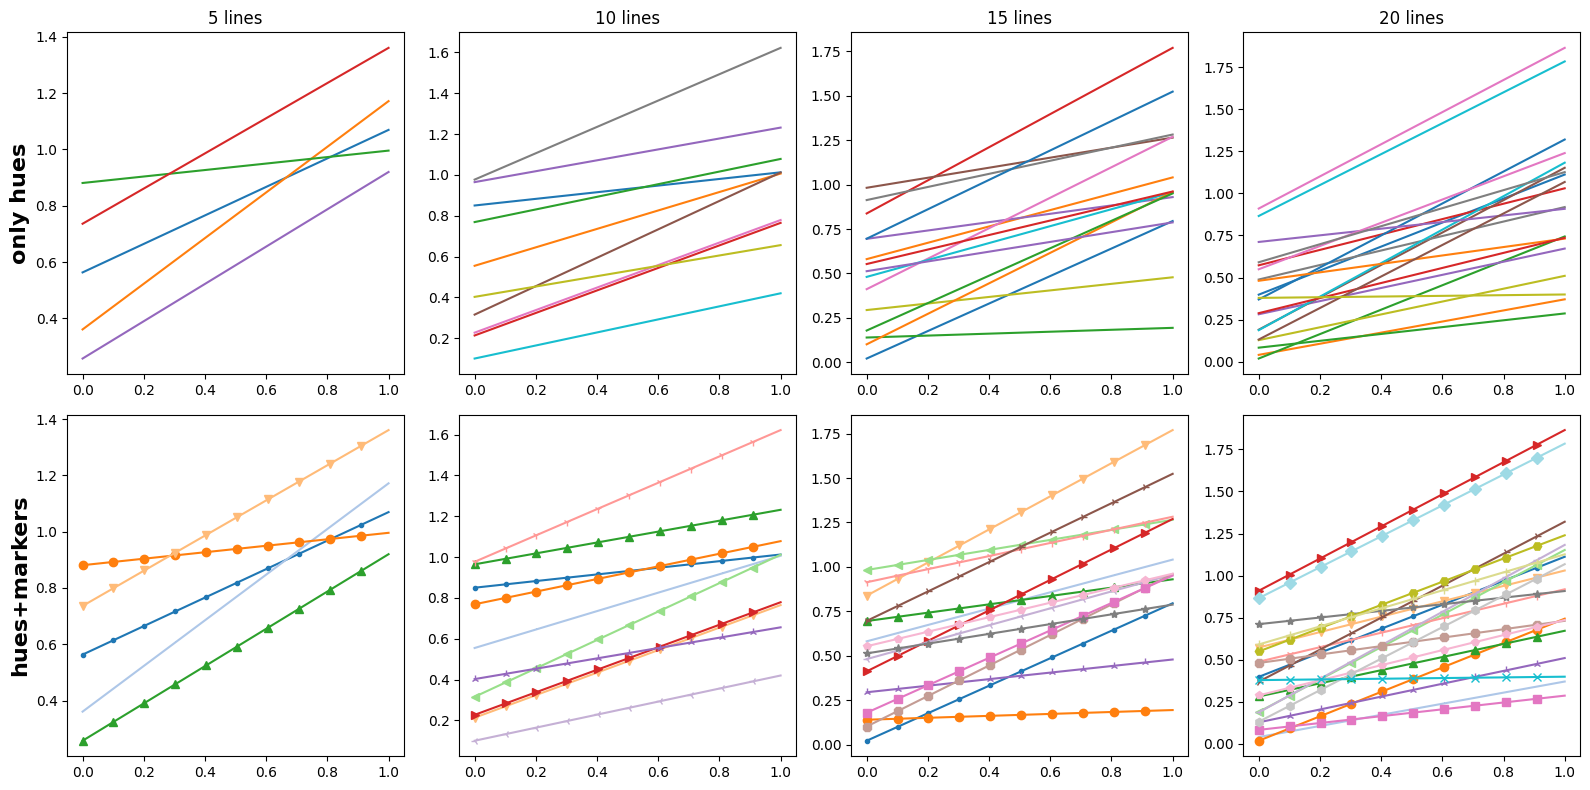

In [9]:
colors = matplotlib.cm.tab20(range(20))
markers = list(matplotlib.lines.Line2D.markers.keys())
x = np.linspace(0,1,100)
print(colors[0])
print(markers)
print(markers[0])
#print("hello", [c[0][0] for c in zip(colors)])
fig, axs = plt.subplots(2,4, figsize=(4*4,4*2))
for nlines,ax0 in zip(np.arange(5,21,5), axs.T):
    ax0[0].set_title('{:d} lines'.format(nlines))
    for n,c,m in zip(range(nlines),colors,markers):
        y = x*np.random.random()+np.random.random()
        ax0[0].plot(x,y)
        ax0[1].plot(x,y, c=c, marker=m, markevery=10)
axs[0,0].set_ylabel('only hues', fontsize=16, fontweight='bold')
axs[1,0].set_ylabel('hues+markers', fontsize=16, fontweight='bold')
fig.tight_layout()

In [10]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def add_inset_zoom(
    ax,
    main_curves,
    inset_curves=None,
    inset_loc="upper right",
    inset_size=("45%", "45%"),
    xlim=None,
    ylim=None,
    mode="zoom_in",          # "zoom_in" or "zoom_out"
    connect=True,
    connect_kwargs=None,
    inset_kwargs=None,
):
    """
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to place the inset into.

    main_curves : list[dict]
        List of curve specs for the main axes. Each item:
        {"x": x, "y": y, "plot_kwargs": {...}}  (plot_kwargs optional)

    inset_curves : list[dict] or None
        If None, uses main_curves. Same format as main_curves.

    inset_loc : str
        Inset location (e.g. "upper right", "lower left", ...)

    inset_size : tuple[str, str]
        (width, height) as percentages or inches, e.g. ("40%","40%") or (1.6,1.2)

    xlim, ylim : tuple[float,float] or None
        Limits to apply to the zoomed region (for the inset if mode="zoom_in",
        for the main ax if mode="zoom_out").

    mode : str
        "zoom_in": inset shows (xlim, ylim); main stays as-is.
        "zoom_out": main shows (xlim, ylim); inset shows full (auto) view.

    connect : bool
        Draw connector lines between inset and main region.

    connect_kwargs : dict or None
        Passed to mark_inset, e.g. {"loc1": 2, "loc2": 4, "fc": "none", "ec": "0.5"}.
        Note: avoid specifying colors if you want default styling.

    inset_kwargs : dict or None
        Passed to inset_axes; rarely needed.
    """
    if inset_curves is None:
        inset_curves = main_curves

    if inset_kwargs is None:
        inset_kwargs = {}

    # Create inset axes
    axins = inset_axes(
        ax,
        width=inset_size[0],
        height=inset_size[1],
        loc=inset_loc,
        borderpad=1.0,
        **inset_kwargs
    )

    # Plot on main axes (if not already plotted outside, you can skip this block)
    for c in main_curves:
        ax.plot(c["x"], c["y"], **c.get("plot_kwargs", {}))

    # Plot on inset axes
    for c in inset_curves:
        axins.plot(c["x"], c["y"], **c.get("plot_kwargs", {}))

    # Apply limits depending on mode
    if mode == "zoom_in":
        if xlim is not None:
            axins.set_xlim(*xlim)
        if ylim is not None:
            axins.set_ylim(*ylim)
    elif mode == "zoom_out":
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        # inset shows full view: let autoscale handle it
        axins.relim()
        axins.autoscale_view()
    else:
        raise ValueError("mode must be 'zoom_in' or 'zoom_out'")

    # Nice: fewer ticks in inset
    axins.tick_params(labelsize=9)

    # Connect inset to ROI on main
    if connect and (xlim is not None) and (ylim is not None):
        mk = dict(loc1=2, loc2=4)  # corners; tweak if needed
        if connect_kwargs:
            mk.update(connect_kwargs)
        mark_inset(ax, axins, **mk)

    return axins

In [11]:
def plot_pot_den_diff(workdir: Path, initial_run_dir: Optional[str], opt_run_dir: Optional[str], per_den_y_lim, den_ylim ) -> Optional[Path]:
    """
    Plot density differences and absolute densities before/after optimization
    in a vertical 3-panel figure.
    Saves PDF + PNG in workdir and returns the PNG path for Markdown embedding.
    """
    colors = matplotlib.cm.tab20(range(20))
    markers = list(matplotlib.lines.Line2D.markers.keys())


    workdir = workdir.resolve()
    before = workdir / initial_run_dir if initial_run_dir else None
    after = workdir / opt_run_dir if opt_run_dir else None

    if not before or not after or not before.exists() or not after.exists():
        print(f"[WARN] Cannot plot densities: missing initial or optimized run dirs")
        return None
    #time.sleep(2) 
    try:
        den_ks_b = pd.read_csv(before / "rho_ks-total-final-z.csv")
        den_ref_b = pd.read_csv(before / "rho_ref-total-final-z.csv")
        den_ks_a = pd.read_csv(after / "rho_ks-total-final-z.csv")
        den_ref_a = pd.read_csv(after / "rho_ref-total-final-z.csv")
        pot_ks_b = pd.read_csv(before / "vxc-total-final-z.csv")
        pot_ks_a = pd.read_csv(after / "vxc-total-final-z.csv")
        pot_ref_b = pd.read_csv(before / "vref-total-final-z.csv")
        pot_ref_a = pd.read_csv(after / "vref-total-final-z.csv")
        
    except Exception as e:
        print(f"[WARN] Failed to load CSV files: {e}")
        return None

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # 2. Absolute densities
    #axes[0].plot(den_ks_b.z, den_ref_b.value, color="black", label="Ref")
    #axes[0].plot(den_ks_b.z, den_ks_b.value, color="orangered", label="Init KS")
    #axes[0].plot(den_ks_a.z, den_ks_a.value, color="dodgerblue", label="Opt KS")
    #axes[0].set_ylabel("Density", fontsize=14)
    #axes[0].legend(frameon=False, fontsize=12)


    # 1. Density difference (Δρ)
    init_percent_den_diff = abs(den_ref_b.value - den_ks_b.value)*100/den_ref_b.value
    opt_percent_den_diff = abs(den_ref_a.value - den_ks_a.value)*100/den_ref_a.value

    main_curves_den = [
        {"x": den_ks_b.z, "y": init_percent_den_diff,
         "plot_kwargs": {"label": "Init Δρ"}},
        {"x": den_ks_a.z, "y": opt_percent_den_diff,
         "plot_kwargs": {"label": "Opt. Δρ"}},
    ]



    # Example: zoom into [-2,2] and y in [0,0.03] INSIDE axes[0,0]
    add_inset_zoom(
        axes[0],
        main_curves_den,
        xlim=(-2, 2),
        ylim=per_den_y_lim,
        mode="zoom_out",
        inset_loc="upper right",
        inset_size=("30%", "30%"),
        connect=False,
    )
    axes[0].set_xlabel("r (Bohr)", fontsize=14)
    axes[0].set_ylabel("% Δ Density", fontsize=14)
    axes[0].legend(frameon=False, fontsize=12)
    axes[0].set_ylim(per_den_y_lim[0], per_den_y_lim[1])
    #axes[0].set_xlim(-8, 8)


    main_curves_den_val = [
        {"x": den_ks_b.z, "y": den_ref_b.value - den_ks_b.value,
         "plot_kwargs": {"label": "Init Δρ"}},
        {"x": den_ks_a.z, "y": den_ref_a.value - den_ks_a.value,
         "plot_kwargs": {"label": "Opt. Δρ"}},
    ]

    add_inset_zoom(
        axes[1],
        main_curves_den_val,
        xlim=(-2, 2),
        ylim = den_ylim,
        mode="zoom_out",
        inset_loc="lower right",
        inset_size=("30%", "30%"),
        connect=False,
    )
    axes[1].set_xlabel("r (Bohr)", fontsize=14)
    axes[1].set_ylabel("Δ Density", fontsize=14)
    axes[1].legend(frameon=False, fontsize=12)
    #axes[1].set_xlim(-2, 2)

    main_curves_pot = [
        {"x": den_ks_b.z, "y": pot_ks_b.value,
         "plot_kwargs": {"label": "Initial Vxc"}},
        {"x": den_ks_a.z, "y": pot_ks_a.value,
         "plot_kwargs": {"label": "Opt Vxc"}},
        {"x": den_ks_b.z, "y": pot_ref_b.value,
         "plot_kwargs": {"label": "Init ref pot"}},
        {"x": den_ks_a.z, "y": pot_ref_a.value,
         "plot_kwargs": {"label": "Opt. ref pot"}},
    ]

    add_inset_zoom(
        axes[2],
        main_curves_pot,
        xlim = (-0.5, 0.5),
        ylim = None,
        mode="zoom_in",
        inset_loc="lower right",
        inset_size=("30%", "30%"),
        connect=False,
    )

    axes[2].set_ylabel("Potential (Ha)", fontsize=14)
    axes[2].legend(frameon=False, fontsize=12)
    #axes[2].set_xlim(-8, 8)
    axes[2].set_xlabel("r (Bohr)", fontsize=14)
    axes[2].set_xlim(-2, 2)
    #axes[1].set_ylim(-, 2)
    
    #axes[0][0].plot(den_ks_b.z, init_percent_den_diff,
    #             color="orangered", label="Init Δρ")
    #axes[0][0].plot(den_ks_a.z, opt_percent_den_diff ,
    #             color="dodgerblue", label="Opt. Δρ")
    #axes[0][0].set_ylabel("% Δ Density", fontsize=14)
    #axes[0][0].legend(frameon=False, fontsize=12)
    #axes[0][0].set_ylim(per_den_y_lim[0],per_den_y_lim[1])
    #axes[0][1].plot(den_ks_b.z, init_percent_den_diff,
    #             color="orangered", label="Init Δρ")
    #axes[0][1].plot(den_ks_a.z, opt_percent_den_diff ,
    #             color="dodgerblue", label="Opt. Δρ")
    #axes[0][1].set_ylabel("% Δ Density", fontsize=14)
    #axes[0][1].legend(frameon=False, fontsize=12)
    #axes[0][0].set_ylim(per_den_y_lim[0],per_den_y_lim[1])

    
    # 1. Density difference (Δρ)
    #axes[1][0].plot(den_ks_b.z, den_ref_b.value - den_ks_b.value,
    #             color="orangered", label="Init Δρ")
    #axes[1][0].plot(den_ks_a.z, den_ref_a.value - den_ks_a.value,
    #             color="dodgerblue", label="Opt. Δρ")
    #axes[1][0].set_ylabel("Δ Density", fontsize=14)
    #axes[1][0].legend(frameon=False, fontsize=12)
    #axes[1][0].set_ylim(den_ylim[0],den_ylim[1])
    #axes[1][1].plot(den_ks_b.z, den_ref_b.value - den_ks_b.value,
    #             color="orangered", label="Init Δρ")
    #axes[1][1].plot(den_ks_a.z, den_ref_a.value - den_ks_a.value,
    #             color="dodgerblue", label="Opt. Δρ")
    #axes[1][1].set_ylabel("Δ Density", fontsize=14)
    #axes[1][1].legend(frameon=False, fontsize=12)
    #axes[1][0].set_ylim(den_ylim[0],den_ylim[1])

    # 3. Potentials
    #axes[2][0].plot(pot_ks_b.z, pot_ks_b.value, color="orangered", label="Initial Vxc")
    #axes[2][0].plot(pot_ks_a.z, pot_ks_a.value, color="dodgerblue", label="Optimized Vxc")
    #axes[2][0].plot(pot_ks_b.z, pot_ref_b.value, color="black",  label="Initial Vref")
    #axes[2][0].plot(pot_ks_a.z, pot_ref_a.value, color=colors[1],  label="Optimized Vref")
    ##axes[2][0].plot(pot_ks_a.z, (pot_ref_b.value-pot_ref_a.value)*100, color="black", label="Diff Vref")
    #axes[2][0].set_ylabel("Potential (Ha)", fontsize=14)
    #axes[2][0].set_xlabel("r (Bohr)", fontsize=14)
    #axes[2][0].legend(frameon=False, fontsize=12)
    #axes[2][0].set_ylim(-4-1,1.0)


#    axes[2][1].plot(pot_ks_b.z, pot_ks_b.value, color="orangered", label="Initial Vxc")
#    axes[2][1].plot(pot_ks_a.z, pot_ks_a.value, color="dodgerblue", label="Optimized Vxc")
#    axes[2][1].plot(pot_ks_b.z, pot_ref_b.value, color="black", marker="o", markersize=3, label="Initial Vref")
#    axes[2][1].plot(pot_ks_a.z, pot_ref_a.value, color=colors[1],  label="Optimized Vref")
#    #axes[2][1].plot(pot_ks_a.z, (pot_ref_b.value-pot_ref_a.value)*100, color="black", label="Diff Vref")
#    axes[2][1].set_ylabel("Potential (Ha)", fontsize=14)
#    axes[2][1].set_xlabel("r (Bohr)", fontsize=14)
#    axes[2][1].legend(frameon=False, fontsize=12)
#    axes[2][1].set_ylim(-4-1,1.0)
    
    # Shared limits
    #for i in range(3):
    #    axes[i][0].set_xlim(-3,3)
    #for i in range(3):
    #    axes[i][1].set_xlim(-8,8)
#    for row in range(3):
#        axes[row, 0].set_xlim(-.52, .52)
#        axes[row, 0].set_xlim(-2, 2)
#        #axes[row, 1].set_xlim(-8, 8)

#    axes[0, 1].set_xlim(-8, 8)
#    axes[1, 1].set_xlim(-8, 8)
#    axes[2, 1].set_xlim(-0.5, 0.5)
    plt.tight_layout()

    out_pdf = workdir / "den_pot_panel.pdf"
    out_png = workdir / "den_pot_panel.png"

    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=200)
    plt.show()
    plt.close(fig)

    #print(f"[INFO] Saved 3-panel density/potential plots → {out_pdf}, {out_png}")
    return out_png



In [12]:
def plot_pot_den_single(dirpath, per_den_y_lim, den_ylim ) -> Optional[Path]:

    try:
        den_ks = pd.read_csv(dirpath / "rho_ks-total-final-z.csv")
        den_ref = pd.read_csv(dirpath / "rho_ref-total-final-z.csv")
        pot_ks = pd.read_csv(dirpath / "vxc-total-final-z.csv")
        pot_ref = pd.read_csv(dirpath / "vref-total-final-z.csv")
    except Exception as e:
        print(f"[WARN] Failed to load CSV files: {e}")
        return None
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))

    # 1. Density difference (Δρ)
    percent_den_diff = abs(den_ref.value - den_ks.value)*100/den_ref.value
    axes[0][0].plot(den_ks.z, percent_den_diff,
                 color="orangered", label="Δρ")
    axes[0][0].set_ylabel("% Δ Density", fontsize=14)
    axes[0][0].legend(frameon=False, fontsize=12)
    axes[0][0].set_ylim(per_den_y_lim[0],per_den_y_lim[1])

    axes[0][1].plot(den_ks.z, percent_den_diff,
                 color="orangered", label="Δρ")
    axes[0][1].set_ylabel("% Δ Density", fontsize=14)
    axes[0][1].legend(frameon=False, fontsize=12)
    #axes[0][0].set_ylim(per_den_y_lim[0],per_den_y_lim[1])

    
    # 1. Density difference (Δρ)
    axes[1][0].plot(den_ks.z, den_ref.value - den_ks.value,
                 color="orangered", label="Δρ")
    axes[1][0].set_ylabel("Δ Density", fontsize=14)
    axes[1][0].legend(frameon=False, fontsize=12)
    axes[1][0].set_ylim(den_ylim[0],den_ylim[1])
    axes[1][1].plot(den_ks.z, den_ref.value - den_ks.value,
                 color="orangered", label="Δρ")
    axes[1][1].set_ylabel("Δ Density", fontsize=14)
    axes[1][1].legend(frameon=False, fontsize=12)
    #axes[1][0].set_ylim(den_ylim[0],den_ylim[1])

    # 3. Potentials
    axes[2][0].plot(pot_ks.z, pot_ks.value, color="orangered", label="Vxc")
    axes[2][0].plot(pot_ks.z, pot_ref.value, color="orangered", label="Initial Vref")
    
    axes[2][0].set_ylabel("Potential (Ha)", fontsize=14)
    axes[2][0].set_xlabel("r (Bohr)", fontsize=14)
    axes[2][0].legend(frameon=False, fontsize=12)
    axes[2][0].set_ylim(-.250,0.25)


    axes[2][1].plot(pot_ks.z, pot_ks.value, color="orangered", label="Vxc")
    axes[2][1].plot(pot_ks.z, pot_ref.value, color="orangered", label="Initial Vref")
    axes[2][1].set_ylabel("Potential (Ha)", fontsize=14)
    axes[2][1].set_xlabel("r (Bohr)", fontsize=14)
    axes[2][1].legend(frameon=False, fontsize=12)
    axes[2][1].set_ylim(-.25,0.25)
    
    # Shared limits
    #for i in range(3):
    #    axes[i][0].set_xlim(-3,3)
    #for i in range(3):
    #    axes[i][1].set_xlim(-8,8)
    for row in range(3):
#        axes[row, 0].set_xlim(-.52, .52)
        axes[row, 0].set_xlim(-20, 20)
        #axes[row, 1].set_xlim(-8, 8)

    axes[0, 1].set_xlim(-8, 8)
    axes[1, 1].set_xlim(-8, 8)
    axes[2, 1].set_xlim(-3.5, 3.5)
    plt.tight_layout()

    out_pdf = dirpath / "den_pot_panel.pdf"
    out_png = dirpath / "den_pot_panel.png"

    plt.savefig(out_pdf)
    plt.savefig(out_png, dpi=200)
    plt.show()
    plt.close(fig)

    #print(f"[INFO] Saved 3-panel density/potential plots → {out_pdf}, {out_png}")
    return out_png

In [13]:
"""
plot_optimizer_diagnostics  —  clean publication edition
=========================================================
Design principles:
  - Off-white background, crisp axes, minimal chrome
  - Okabe-Ito colour palette (colourblind safe)
  - Tight proportions: strip is ~1/5 the height of a data row
  - rsqr_scaled_dnorm on its own panel to prevent y-axis compression
  - All exponent panels in log10 (linear is useless when one exp >> others)
  - Gradient panels use semilogy
  - Best-iteration gold star on score panel
  - Bottom heatstrip for score_w_penalty history
"""

from __future__ import annotations

import warnings
from typing import Any, Dict, List, Optional, Sequence

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np


# ── Okabe-Ito palette (8 colours, colourblind safe) ──────────────────────────
_OI = [
    "#0072B2",   # 0  deep blue
    "#E69F00",   # 1  amber
    "#009E73",   # 2  teal green
    "#D55E00",   # 3  vermillion
    "#CC79A7",   # 4  rose
    "#56B4E9",   # 5  sky blue
    "#F0E442",   # 6  yellow  (use sparingly on light bg)
    "#000000",   # 7  black
    "#FF4500",   # 8  orange
    "#1E90FF",   # 9  dodger blue   
]
_MARKERS  = markers = list(matplotlib.lines.Line2D.markers.keys())
_LW       = 1.5
_MS       = 7


# ── RC context ────────────────────────────────────────────────────────────────
_RC = {
    "figure.facecolor":    "#F7F5F0",
    "axes.facecolor":      "#FFFFFF",
    "axes.edgecolor":      "#999999",
    "axes.linewidth":      0.8,
    "axes.labelcolor":     "#222222",
    "axes.titlecolor":     "#111111",
    "axes.titlesize":      10,
    "axes.titleweight":    "bold",
    "axes.labelsize":      8.5,
    "axes.titlepad":       6,
    "axes.grid":           True,
    "grid.color":          "#CCCCCC",
    "grid.linewidth":      0.5,
    "grid.linestyle":      "--",
    "xtick.color":         "#555555",
    "ytick.color":         "#555555",
    "xtick.labelsize":     7.5,
    "ytick.labelsize":     7.5,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "legend.facecolor":    "#FFFFFF",
    "legend.edgecolor":    "#BBBBBB",
    "legend.fontsize":     7.5,
    "legend.framealpha":   0.9,
    "legend.handlelength": 1.6,
    "lines.linewidth":     _LW,
    "lines.markersize":    _MS,
    "font.family":         "sans-serif",
    "font.sans-serif":     ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi":          130,
}


# ── helpers ───────────────────────────────────────────────────────────────────
def _style(ax: plt.Axes, title: str, xlabel: str, ylabel: str,
           logy: bool = False) -> None:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if logy:
        ax.set_yscale("log")


def _plot_lines(ax: plt.Axes, x: np.ndarray,
                series: dict,
                logy: bool = False,
                palette_offset: int = 0) -> None:
    me = max(1, len(x) // 20)
    for k, (key, arr) in enumerate(series.items()):
        idx = (k + palette_offset) % len(_OI)
        ax.plot(x, arr,
                color=_OI[idx], marker=_MARKERS[idx % len(_MARKERS)],
                markevery=me, linewidth=_LW, markersize=_MS,
                label=key, zorder=3)
    if logy:
        ax.set_yscale("log")



# ── grad.log reader + standalone plotter ─────────────────────────────────────
def read_grad_log(path: str) -> "tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]":
    """
    Parse a grad.log file whose lines have the format::

        iter   f   gnorm   g[0]   g[1]   ...   g[K-1]

    Column layout
    -------------
    0     : iteration index  (int)
    1     : objective value f (float)
    2     : gradient norm  ||g||  (float, pre-computed by the optimizer)
    3..   : individual gradient components g[0], g[1], ...

    Returns
    -------
    iters   : int array   (N,)
    scores  : float array (N,)   — objective f
    gnorms  : float array (N,)   — gradient norm from file (column 2)
    grads   : float array (N, K) — components g[0..K-1], NaN-padded if ragged
    """
    iters_l:  list = []
    scores_l: list = []
    gnorms_l: list = []
    grads_l:  list = []

    with open(path, "r") as fh:
        for lineno, raw in enumerate(fh, start=1):
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 3:
                warnings.warn(f"grad.log line {lineno}: only {len(parts)} columns, skipped")
                continue
            try:
                iters_l.append(int(parts[0]))
                scores_l.append(float(parts[1]))
                gnorms_l.append(float(parts[2]))
                grads_l.append([float(x) for x in parts[3:]])
            except ValueError as exc:
                warnings.warn(f"grad.log line {lineno}: {exc}, skipped")

    if not iters_l:
        raise ValueError(f"No valid data in {path!r}")

    maxK = max((len(g) for g in grads_l), default=0)
    grads_arr = np.full((len(grads_l), max(maxK, 1)), np.nan)
    for i, g in enumerate(grads_l):
        if g:
            grads_arr[i, : len(g)] = g

    return (np.array(iters_l, dtype=int),
            np.array(scores_l, dtype=float),
            np.array(gnorms_l, dtype=float),
            grads_arr)


def plot_grad_log(
    path: str,
    title: str = "Gradient log",
    max_components: int = 20,
    show: bool = True,
    savepath: Optional[str] = None,
) -> plt.Figure:
    """
    Read a grad.log file (format: iter  f  gnorm  g[0]  g[1]  ...) and
    produce a 3-panel diagnostic figure.

    Panels
    ------
    Top-left  : objective f vs iteration (auto log-scale if range > 2 decades)
    Top-right : gradient norm vs iteration (semilogy); file gnorm + recomputed
                ||g||_2 overlaid as a cross-check — they should be identical.
    Bottom    : log10|g[i]| for each component, capped at max_components.
    """
    iters, scores, gnorms, grads = read_grad_log(path)
    print(path.replace("grad.log", "coeff.log"))
    _,_,_, coeff = read_grad_log(path.replace("grad.log", "coeff.log"))
    #print(coeff)
    it = iters.astype(float)
    K  = grads.shape[1]
    
    # recompute norm from components as a cross-check
    gnorm_check = np.sqrt(np.nansum(grads ** 2, axis=1))
    has_comp    = np.any(np.isfinite(grads), axis=1)
    gnorm_check = np.where(has_comp, gnorm_check, np.nan)

    with matplotlib.rc_context(_RC):
        fig = plt.figure(figsize=(18, 14))
        gs  = gridspec.GridSpec(
            3, 2,
            height_ratios=[1.0, 1.4, 1.0],
            hspace=0.44, wspace=0.28,
            left=0.08, right=0.97,
            top=0.92,  bottom=0.06,
        )
        ax_score = fig.add_subplot(gs[0, 0])
        ax_norm  = fig.add_subplot(gs[0, 1])
        ax_comp  = fig.add_subplot(gs[1, :])
        ax_coeff  = fig.add_subplot(gs[2, :])

        me = max(1, len(it) // 25)

        # ── top-left: objective f ──────────────────────────────────────────
        s_pos   = scores[scores > 0]
        use_log = len(s_pos) > 1 and np.log10(s_pos.max() / s_pos.min()) > 2.0
        ax_score.plot(it, scores, color=_OI[0], marker="o",
                      markevery=me, lw=_LW, ms=_MS)
        best = int(np.nanargmin(scores))
        ax_score.scatter(it[best], scores[best], s=160, marker="*",
                         color="#C8A200", zorder=5,
                         label=f"best  (it={iters[best]})", edgecolors="none")
        _style(ax_score, "Objective  f", "iteration", "f", logy=use_log)
        ax_score.legend(loc="upper right")

        # ── top-right: gradient norm ───────────────────────────────────────
        ax_norm.plot(it, gnorms, color=_OI[3], marker="s",
                     markevery=me, lw=_LW, ms=_MS, label="gnorm  (file col 2)")
        if np.any(np.isfinite(gnorm_check)):
            ax_norm.plot(it, gnorm_check, color=_OI[4], marker="^",
                         markevery=me, lw=1.0, ms=_MS - 1, ls="--",
                         label="||g||2  (recomputed)", zorder=2)
        _style(ax_norm, "Gradient norm", "iteration", "||g||", logy=True)
        ax_norm.legend(loc="upper right")

        # ── bottom: components in log10 ────────────────────────────────────
        n_show      = min(K, max_components)
        any_plotted = False
        for j in range(n_show):
            col = grads[:, j]
            if not np.any(np.isfinite(col)):
                continue
            any_plotted = True
            c = _OI[j % len(_OI)]
            m = _MARKERS[j % len(_MARKERS)]
            #print(m)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                log_abs = np.where(col != 0, np.log10(np.abs(col)), np.nan)
            ax_comp.plot(it, log_abs, color=c, marker=m,
                         markevery=me, lw=_LW - 0.3, ms=_MS - 1,
                         label=f"g[{j}]")
            #ax_coeff.plot(it, log_abs, color=c, marker=m,
            #             markevery=me, lw=_LW - 0.3, ms=_MS - 1,
            #             label=f"g[{j}]")

        if any_plotted:
            ax_comp.axhline(np.log10(1e-5), color="#AAAAAA", lw=0.7,
                            ls=":", label="10-5 ref")
            comp_title = ("Gradient components  log10|g[i]|"
                          + (f"  (first {n_show} of {K})" if n_show < K else ""))
            _style(ax_comp, comp_title, "iteration", "log10|g[i]|")
            ncol = min(4, max(1, n_show // 3))
            if n_show <= 16:
                ax_comp.legend(ncol=ncol, loc="best", fontsize=7.5)
            else:
                ax_comp.text(0.01, 0.97, f"Showing first {n_show} of {K} components",
                             transform=ax_comp.transAxes, va="top",
                             color="#555555", fontsize=8)
        else:
            ax_comp.text(0.5, 0.5,
                         "No individual gradient components in file\n"
                         "(file has iter / f / gnorm only)",
                         transform=ax_comp.transAxes,
                         ha="center", va="center", color="#777777", fontsize=10)
            _style(ax_comp, "Gradient components", "iteration", "log10|g[i]|")

         #── bottom: components in log10 ────────────────────────────────────
        n_show      = min(K, max_components)
        any_plotted = False
        for j in range(n_show):
            col = coeff[:, j]
            if not np.any(np.isfinite(col)):
                continue
            any_plotted = True
            c = _OI[j % len(_OI)]
            m = _MARKERS[j % len(_MARKERS)]
            print(m)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                log_abs = np.where(col != 0, np.log10(np.abs(col)), np.nan)
            ax_coeff.plot(it, log_abs, color=c, marker=m,
                         markevery=me, lw=_LW - 0.3, ms=_MS - 1,
                         label=f"g[{j}]")
            #ax_coeff.plot(it, log_abs, color=c, marker=m,
            #             markevery=me, lw=_LW - 0.3, ms=_MS - 1,
            #             label=f"g[{j}]")
#
        if any_plotted:
            #ax_coeff.axhline(np.log10(1e-5), color="#AAAAAA", lw=0.7,
            #                ls=":", label="10-5 ref")
            comp_title = ("Coefficient components "
                          + (f"  (first {n_show} of {K})" if n_show < K else ""))
            _style(ax_coeff, comp_title, "iteration", "log10|g[i]|")
            ncol = min(4, max(1, n_show // 3))
            if n_show <= 16:
                ax_coeff.legend(ncol=ncol, loc="best", fontsize=7.5)
            else:
                ax_coeff.text(0.01, 0.97, f"Showing first {n_show} of {K} components",
                             transform=ax_coeff.transAxes, va="top",
                             color="#555555", fontsize=8)
        else:
            ax_coeff.text(0.5, 0.5,
                         "No individual coefficient components in file\n"
                         "(file has iter / f / gnorm only)",
                         transform=ax_coeff.transAxes,
                         ha="center", va="center", color="#777777", fontsize=10)
            _style(ax_coeff, "Coefficient components", "iteration", "log10|g[i]|")
#
        fig.suptitle(title, fontsize=13, fontweight="bold", color="#111111")

        if savepath:
            fig.savefig(savepath, dpi=200, bbox_inches="tight",
                        facecolor=fig.get_facecolor())
        if show:
            plt.show()
            plt.close(fig)

    return fig

# ── main ──────────────────────────────────────────────────────────────────────
def plot_optimizer_diagnostics(
    runs: List[Dict[str, Any]],
    grad_list: Optional[List] = None,
    metrics_to_plot: Sequence[str] = (
        "dnorm", "rscaled_dnorm", "rtimes_scaled_dnorm", "rsqr_scaled_dnorm","ref_proj_dnorm","ref_proj_rscaled_dnorm","ref_proj_rtimes_scaled_dnorm","ref_proj_rsqr_scaled_dnorm"
    ),
    title: str = "OEP optimiser diagnostics",
    logy_score:   bool = False,
    logy_metrics: bool = True,
    show:         bool = True,
    savepath:     Optional[str] = None,
) -> plt.Figure:
    if not runs:
        raise ValueError("runs is empty")
    with matplotlib.rc_context(_RC):
        return _build(runs, grad_list, list(metrics_to_plot),
                      title, logy_score, logy_metrics, show, savepath)


def _build(runs, grad_list, metrics_to_plot,
           title, logy_score, logy_metrics, show, savepath):

    n  = len(runs)
    it = np.arange(n, dtype=float)

    # ── data extraction ───────────────────────────────────────────────────────
    score    = np.array([r.get("score",          np.nan) for r in runs], float)
    score_wp = np.array([r.get("score_w_penalty", np.nan) for r in runs], float)
    penalty  = np.where(np.isfinite(score) & np.isfinite(score_wp),
                        score_wp - score, np.nan)

    K = np.array([r.get("K", np.nan) for r in runs], float)

    def _extract(field: str) -> dict:
        out = {}
        for key in metrics_to_plot:
            arr = np.full(n, np.nan)
            for i, r in enumerate(runs):
                md = r.get(field) or {}
                if key in md:
                    arr[i] = float(md[key])
            out[key] = arr
        return out

    metric_series = _extract("metrics")
    score_series  = _extract("score_parts")

    maxK = int(np.nanmax(K)) if np.any(np.isfinite(K)) else 0
    exps_mat = np.full((n, maxK), np.nan)
    for i, r in enumerate(runs):
        for j, v in enumerate((r.get("exps") or [])[:maxK]):
            exps_mat[i, j] = float(v)

    n_grad   = len(grad_list) if grad_list else 0
    it_grad  = np.arange(n_grad, dtype=float) if n_grad else None
    grad_mat = np.full((max(n_grad, 1), maxK), np.nan)
    if grad_list:
        for i, g in enumerate(grad_list):
            for j, v in enumerate(g[:maxK]):
                grad_mat[i, j] = float(v)

    rsqr_keys  = [k for k in metrics_to_plot if "rsqr" in k.lower()]
    other_keys = [k for k in metrics_to_plot if "rsqr" not in k.lower()]
    print(f"Metrics to plot: {other_keys} (dnorm family), {rsqr_keys} (near-nuclear)")

    # ── layout: 5 rows × 2 cols ───────────────────────────────────────────────
    # height_ratios: 4 equal data rows + 1 thin strip (0.22 of one row)
    fig = plt.figure(figsize=(18, 22))
    gs  = gridspec.GridSpec(
        3, 2,
        height_ratios=[1.0, 1.0, 1.0],
        hspace=0.52,
        wspace=0.28,
        left=0.08, right=0.97,
        top=0.94,  bottom=0.04,
    )

    ax_score = fig.add_subplot(gs[0, 0])
    ax_pen   = fig.add_subplot(gs[0, 1])
    ax_met   = fig.add_subplot(gs[1, 0])
    ax_rsqr  = fig.add_subplot(gs[1, 1])
    ax_scr   = fig.add_subplot(gs[2, 0])
    ax_exp   = fig.add_subplot(gs[2, 1])
    #ax_grad  = fig.add_subplot(gs[3, 0])
    #ax_glog  = fig.add_subplot(gs[3, 1])
    #ax_strip = fig.add_subplot(gs[4, :])

    me = max(1, n // 20)

    # ── row 0 left: score ─────────────────────────────────────────────────────
    ax_score.plot(it, score,    color=_OI[0], marker="o",
                  markevery=me, lw=_LW, ms=_MS, label="score (no penalty)")
    ax_score.plot(it, score_wp, color=_OI[1], marker="s",
                  markevery=me, lw=_LW, ms=_MS, ls="--", label="score + penalty")
    best = (int(np.nanargmin(score_wp))
            if np.any(np.isfinite(score_wp)) else None)
    if best is not None:
        ax_score.scatter(it[best], score_wp[best],
                         s=160, marker="*", color="#C8A200",
                         zorder=5, label=f"best  (it={best})", edgecolors="none")
    _style(ax_score, "Objective", "iteration", "score", logy=logy_score)
    ax_score.legend(loc="upper right")

    # ── row 0 right: penalty ──────────────────────────────────────────────────
    ax_pen.plot(it, penalty, color=_OI[2], marker="^",
                markevery=me, lw=_LW, ms=_MS)
    ax_pen.axhline(0, color="#AAAAAA", lw=0.7, ls=":")
    _style(ax_pen, "Penalty  (score_w_penalty − score)", "iteration", "penalty")

    # ── row 1 left: dnorm family ──────────────────────────────────────────────
    _plot_lines(ax_met, it, {k: metric_series[k] for k in other_keys},
                logy=logy_metrics)
    _style(ax_met, "Density-norm metrics", "iteration", "metric value",
           logy=logy_metrics)
    ax_met.legend(loc="upper right")

    # ── row 1 right: rsqr ────────────────────────────────────────────────────
    if rsqr_keys:
        _plot_lines(ax_rsqr, it, {k: metric_series[k] for k in rsqr_keys},
                    logy=logy_metrics)
        _style(ax_rsqr, "Near-nuclear metric  (rsqr_scaled)",
               "iteration", "metric value", logy=logy_metrics)
        ax_rsqr.legend(loc="upper right")
    else:
        ax_rsqr.set_visible(False)

    # ── row 2 left: score parts ───────────────────────────────────────────────
    _plot_lines(ax_scr, it, score_series, logy=logy_metrics)
    _style(ax_scr, "Score parts per metric", "iteration",
           "score contribution", logy=logy_metrics)
    ax_scr.legend(loc="upper right")

    # ── row 2 right: exponents in log10 ──────────────────────────────────────
    cols = np.where(np.any(np.isfinite(exps_mat), axis=0))[0]
    me_e = max(1, n // 20)
    for j in cols:
        c = _OI[j % len(_OI)]
        m = _MARKERS[j % len(_MARKERS)]
        ax_exp.plot(it, np.log10(np.abs(exps_mat[:, j])),
                    color=c, marker=m, markevery=me_e,
                    lw=_LW, ms=_MS - 1, label=f"exp[{j}]")
    _style(ax_exp, "Exponent trajectories  (log₁₀ scale)",
           "iteration", "log₁₀(exp)")
    if len(cols) <= 14:
        ax_exp.legend(ncol=3, loc="best")
    else:
        ax_exp.text(0.02, 0.97, f"{len(cols)} traces",
                    transform=ax_exp.transAxes, va="top",
                    color="#666666", fontsize=7)

    # ── row 3: gradients ──────────────────────────────────────────────────────
    #gcols = np.where(np.any(np.isfinite(grad_mat), axis=0))[0]
    #if n_grad > 0 and len(gcols) > 0:
    #    me_g = max(1, n_grad // 20)
    #    for j in gcols:
    #        c = _OI[j % len(_OI)]
    #        m = _MARKERS[j % len(_MARKERS)]
    #        yabs = np.abs(grad_mat[:, j])
    #        ax_grad.semilogy(it_grad, yabs, color=c, marker=m,
    #                         markevery=me_g, lw=_LW, ms=_MS - 1,
    #                         label=f"grad[{j}]")
    #        with warnings.catch_warnings():
    #            warnings.simplefilter("ignore")
    #            log_y = np.where(yabs > 0, np.log10(yabs), np.nan)
    #        ax_glog.plot(it_grad, log_y, color=c, marker=m,
    #                     markevery=me_g, lw=_LW, ms=_MS - 1,
    #                     label=f"grad[{j}]")
    #    _style(ax_grad, "|Gradient|  (semilogy)",    "iteration", "|∇ score|")
    #    _style(ax_glog, "|Gradient|  (log₁₀ scale)", "iteration", "log₁₀|∇|")
    #    if len(gcols) <= 14:
    #        ax_grad.legend(ncol=3, fontsize=7)
   #         ax_glog.legend(ncol=3, fontsize=7)
  #  else:
 #       ax_grad.set_visible(False)
#        ax_glog.set_visible(False)

    # ── row 4: convergence heatstrip ──────────────────────────────────────────
    #_draw_strip(ax_strip, it, score_wp, best)

    fig.suptitle(title, fontsize=13, fontweight="bold", color="#111111")

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    if show:
        plt.show()
        plt.close(fig)

    return fig


def _draw_strip(ax: plt.Axes, it: np.ndarray,
                score_wp: np.ndarray, best: Optional[int]) -> None:
    n      = len(it)
    finite = np.isfinite(score_wp)
    s_norm = np.full(n, 0.5)
    if finite.sum() > 1:
        lo, hi = np.nanmin(score_wp), np.nanmax(score_wp)
        s_norm = np.where(finite,
                          (score_wp - lo) / max(hi - lo, 1e-30), 0.5)

    cmap = matplotlib.colormaps["YlOrRd"]
    for i in range(n):
        ax.bar(i, 1.0, color=cmap(s_norm[i]), width=0.92,
               linewidth=0, zorder=2)

    if best is not None:
        ax.text(best, 0.5, "★", ha="center", va="center",
                fontsize=10, color="#003366", zorder=5, fontweight="bold")

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel("iteration", fontsize=8)
    ax.set_yticks([])
    ax.set_title("score_w_penalty history  "
                 "(yellow = low / good,  red = high / bad,  ★ = best)",
                 fontsize=8.5, fontweight="bold")
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)

    sm = matplotlib.cm.ScalarMappable(
        cmap=cmap,
        norm=matplotlib.colors.Normalize(
            vmin=float(np.nanmin(score_wp)) if finite.any() else 0,
            vmax=float(np.nanmax(score_wp)) if finite.any() else 1,
        )
    )
    cb = ax.get_figure().colorbar(
        sm, ax=ax, orientation="horizontal",
        fraction=0.035, pad=0.55, aspect=70,
    )
    cb.ax.tick_params(labelsize=7)
    cb.set_label("score_w_penalty", fontsize=7.5)

## Write REPORT.md files


In [14]:
def _fmt(v, sci=True):
    if v is None:
        return "—"
    try:
        return f"{v:.5E}" if sci else f"{v:.6g}"
    except Exception:
        return str(v)

def _metrics_row(name, m, keys):
    return [name] + [_fmt(m.get(k) if m else None) for k in keys]

def metrics_markdown_table(
    init_with, init_without, opt_with, opt_without,
    #keys=("dnorm","rscaled_dnorm","rtimes_scaled_dnorm")
    keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm"),
    print_table_heading=True,
    parsing_type=None
):
    if print_table_heading:
        header = ["case"] + list(keys)
    else:
        header = None
    rows = [
        _metrics_row(f"init_rp_{parsing_type}", init_without, keys),
        _metrics_row(f"init_oep_{parsing_type}",    init_with,    keys),
        _metrics_row(f"opt_rp_{parsing_type}",  opt_without,  keys),
        _metrics_row(f"opt_oep_{parsing_type}",     opt_with,     keys),
    ]

    # Markdown table
    lines = []
    if print_table_heading:

        lines.append("| " + " | ".join(header) + " |")
        lines.append("| " + " | ".join(["---"]*len(header)) + " |")
    for r in rows:
        lines.append("| " + " | ".join(r) + " |")
    return "\n".join(lines)

def metrics_markdown_table_3row(
    bl_pV5Z, bl_pVQZ, bl_pVTZ,
    #keys=("dnorm","rscaled_dnorm","rtimes_scaled_dnorm")
    keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm")
):
    header = ["case"] + list(keys)
    rows = [
        _metrics_row("bl_pV5Z_std_oep_thrs", bl_pV5Z, keys),
        _metrics_row("bl_pVQZ_std_oep_thrs", bl_pVQZ, keys),
        _metrics_row("bl_pVTZ_std_oep_thrs", bl_pVTZ, keys),
    ]

    # Markdown table
    lines = []
    lines.append("| " + " | ".join(header) + " |")
    lines.append("| " + " | ".join(["---"]*len(header)) + " |")
    for r in rows:
        lines.append("| " + " | ".join(r) + " |")
    return "\n".join(lines)

def delta_metrics_table(init_with, init_without, opt_with, opt_without,
                        keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm")):
    def delta(a, b):
        if a is None or b is None:
            return None
        try:
            return a - b
        except Exception:
            return None

    def row(name, opt_m, init_m):
        vals = []
        for k in keys:
            ov = opt_m.get(k) if opt_m else None
            iv = init_m.get(k) if init_m else None
            vals.append(_fmt(delta(ov, iv)))
        return [name] + vals

    header = ["delta (opt-init)"] + list(keys)
    rows = [
        row("without_cutoff", opt_without, init_without),
        row("with_cutoff",    opt_with,    init_with),
    ]

    lines = []
    lines.append("| " + " | ".join(header) + " |")
    lines.append("| " + " | ".join(["---"]*len(header)) + " |")
    for r in rows:
        lines.append("| " + " | ".join(r) + " |")
    return "\n".join(lines)


In [15]:
def get_baselines(lines):
    bl_pV5Z_path = Path("/home/mandalia/WORK_DIR/oep-opt-package-test/Orig_basis_9expo_600_w_rtimes/basline_w_threshold").resolve()
    bl_pVQZ_path = Path("/home/mandalia/WORK_DIR/oep-opt-package-test/S_OVERLAP_Penalty_experiment/orig_mp2fit_plus_600_35_25_25_15_eps_1e4_tocontractedAO_basis_quadruple/baseline_w_threshold").resolve()
    bl_pVTZ_path = Path("/home/mandalia/WORK_DIR/oep-opt-package-test/S_OVERLAP_Penalty_experiment/orig_mp2fit_plus_600_35_25_25_15_eps_1e4_tocontractedAO_basis_triple/basline_w_threshold").resolve()
    
    _, bl_pV5Z_std_oep_thrs, _, _, _  = get_metrics_from_output(bl_pV5Z_path)
    _, bl_pVQZ_std_oep_thrs, _, _, _  = get_metrics_from_output(bl_pVQZ_path)
    _, bl_pVTZ_std_oep_thrs, _, _, _  = get_metrics_from_output(bl_pVTZ_path)

    lines.append("### Baseline summary without r cutoff")
    lines.append(metrics_markdown_table_3row(
        bl_pV5Z_std_oep_thrs,
        bl_pVQZ_std_oep_thrs,
        bl_pVTZ_std_oep_thrs,
        keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm","rsqr_scaled_dnorm")
    ))
    return lines

In [16]:
def print_onedir_results(heading, dirpath,debug= False, per_den_y_lim = [0.0,0.15], den_ylim = [-0.125,0.075] ):
    #lines = []
    dirpath = Path(dirpath).resolve()
    if debug:
        print(dirpath)
        print_input(dirpath)
    metrics_w_radial_cutoff, metrics_wo_radial_cutoff ,s_val,_,a_val = get_metrics_from_output(dirpath)
    list_Num_nonsingular_comp_init = get_nonsingular_comp(dirpath)
    keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm","rsqr_scaled_dnorm")
    header = ["case"] + list(keys)
    rows = [
        _metrics_row("metrics_wo_radial_cutoff", metrics_wo_radial_cutoff, keys),
        _metrics_row("metrics_w_radial_cutoff",    metrics_w_radial_cutoff,    keys),
    ]
    
    # Markdown table
    lines = []
    lines = get_baselines(lines)
    lines.append(f"- **Initital First_ev_of_S**: {s_val}")
    lines.append(f"- **Initital optimized (last) First_ev_of_A**: {a_val}")
    lines.append(f"- **Initial run List: Num_nonsingular_comp**: {', '.join(f'{x:.6g}' for x in list_Num_nonsingular_comp_init )}")
    lines.append("| " + " | ".join(header) + " |")
    lines.append("| " + " | ".join(["---"]*len(header)) + " |")
    for r in rows:
        lines.append("| " + " | ".join(r) + " |")
        

    md_text = "\n".join(lines)
    show_upgrade_panel(heading, md_text=md_text, results={},
                    plot_fn=lambda: plot_pot_den_single(dirpath, per_den_y_lim, den_ylim,),
                    plot_fn_diag=None,
                    open_sections=(0,)      # open report first
                )
    return None

In [17]:
#!/usr/bin/env python3
"""
bfgs_hessian_diagnostic.py
==========================
Diagnose BFGS Hessian health from grad.log and coeff.log files.

Reconstructs the BFGS inverse Hessian from the optimization trajectory
and checks for corruption signals.

Usage:
    python bfgs_hessian_diagnostic.py /path/to/opt_log/
    python bfgs_hessian_diagnostic.py /path/to/opt_log/ --plot
"""
#from __future__ import annotations

#import argparse
#import sys
#from pathlib import Path

#import numpy as np


# ──────────────────────────────────────────────────────────────────────
# Parsing
# ──────────────────────────────────────────────────────────────────────

def parse_grad_log(path: Path):
    """
    Parse grad.log.
    Each line: iter  f(x)  ||g||_2  g[0] g[1] ... g[K-1]
    Returns: iters, fvals, gnorms, grads (2D array)
    """
    iters, fvals, gnorms, grads = [], [], [], []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            iters.append(int(parts[0]))
            fvals.append(float(parts[1]))
            gnorms.append(float(parts[2]))
            grads.append([float(x) for x in parts[3:]])
    return (np.array(iters), np.array(fvals), np.array(gnorms),
            np.array(grads))


def parse_coeff_log(path: Path):
    """
    Parse coeff.log.
    Each line: iter  f(x)  ||g||_2  exp[0] exp[1] ... exp[K-1]
    Returns: exps (2D array of exponents per iteration)
    """
    exps = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            exps.append([float(x) for x in parts[3:]])
    return np.array(exps)


# ──────────────────────────────────────────────────────────────────────
# BFGS Hessian reconstruction
# ──────────────────────────────────────────────────────────────────────

def reconstruct_bfgs_hessian(thetas, grads):
    """
    Reconstruct the BFGS inverse Hessian H_k at each iteration from
    the (s_k, y_k) secant pairs.
    
    thetas: (n_iter, K) — parameter values (log-exponents)
    grads:  (n_iter, K) — gradient values
    
    Returns:
        H_history: list of (K, K) inverse Hessian approximations
        diagnostics: list of dicts with per-step diagnostics
    """
    n_iter, K = thetas.shape
    
    # Initialize H_0 = I (scipy default)
    H = np.eye(K)
    
    H_history = [H.copy()]
    diagnostics = []
    
    for k in range(n_iter - 1):
        s_k = thetas[k + 1] - thetas[k]    # step
        y_k = grads[k + 1] - grads[k]      # gradient change
        
        sy = float(np.dot(s_k, y_k))
        yy = float(np.dot(y_k, y_k))
        ss = float(np.dot(s_k, s_k))
        
        # Curvature condition: s^T y > 0 required for valid BFGS update
        curvature_ok = sy > 0
        
        # Angle between step and negative gradient (should be < 90° for descent)
        g_norm = np.linalg.norm(grads[k])
        s_norm = np.linalg.norm(s_k)
        if g_norm > 0 and s_norm > 0:
            cos_step_neg_grad = float(np.dot(s_k, -grads[k]) / (s_norm * g_norm))
        else:
            cos_step_neg_grad = float('nan')
        
        # Gradient direction cosine
        gn1 = np.linalg.norm(grads[k])
        gn2 = np.linalg.norm(grads[k + 1])
        if gn1 > 0 and gn2 > 0:
            cos_grad = float(np.dot(grads[k], grads[k + 1]) / (gn1 * gn2))
        else:
            cos_grad = float('nan')
        
        diag = {
            'iter': k + 1,
            's_norm': float(s_norm),
            'y_norm': float(np.sqrt(yy)),
            'sy': sy,
            'curvature_ok': curvature_ok,
            'cos_step_neg_grad': cos_step_neg_grad,
            'cos_grad_consecutive': cos_grad,
        }
        
        # Perform BFGS update if curvature condition holds
        if curvature_ok and sy > 1e-30:
            rho = 1.0 / sy
            I = np.eye(K)
            V = I - rho * np.outer(s_k, y_k)
            H = V @ H @ V.T + rho * np.outer(s_k, s_k)
            
            # Hessian diagnostics
            eigs_H = np.linalg.eigvalsh(H)
            diag['H_cond'] = float(eigs_H[-1] / max(eigs_H[0], 1e-30))
            diag['H_min_eig'] = float(eigs_H[0])
            diag['H_max_eig'] = float(eigs_H[-1])
            diag['H_updated'] = True
        else:
            # Skipped update (scipy would also skip)
            eigs_H = np.linalg.eigvalsh(H)
            diag['H_cond'] = float(eigs_H[-1] / max(eigs_H[0], 1e-30))
            diag['H_min_eig'] = float(eigs_H[0])
            diag['H_max_eig'] = float(eigs_H[-1])
            diag['H_updated'] = False
        
        # Check if the step direction matches H_k * (-g_k)
        # (If BFGS is working, s_k should be proportional to -H_k @ g_k)
        Hg = H_history[-1] @ (-grads[k])
        if np.linalg.norm(Hg) > 0 and s_norm > 0:
            cos_step_Hg = float(np.dot(s_k, Hg) / (s_norm * np.linalg.norm(Hg)))
        else:
            cos_step_Hg = float('nan')
        diag['cos_step_vs_Hg'] = cos_step_Hg
        
        diagnostics.append(diag)
        H_history.append(H.copy())
    
    return H_history, diagnostics


# ──────────────────────────────────────────────────────────────────────
# Corruption detection
# ──────────────────────────────────────────────────────────────────────

def detect_corruption(diagnostics, fvals):
    """
    Analyze diagnostics for signs of Hessian corruption.
    Returns a list of (severity, message) tuples.
    """
    findings = []
    n = len(diagnostics)
    
    # 1. Curvature violations: s^T y <= 0
    bad_curv = [d for d in diagnostics if not d['curvature_ok']]
    if bad_curv:
        iters = [d['iter'] for d in bad_curv]
        findings.append(('SEVERE',
            f"Curvature condition s^T y > 0 violated at {len(bad_curv)} iterations: "
            f"{iters[:10]}{'...' if len(iters) > 10 else ''}. "
            f"BFGS Hessian update skipped — search direction quality degrades."))
    
    # 2. Gradient direction flips (cosine < -0.5)
    flips = [(d['iter'], d['cos_grad_consecutive'])
             for d in diagnostics if d['cos_grad_consecutive'] < -0.5]
    if flips:
        findings.append(('SEVERE',
            f"Gradient direction flipped (cos < -0.5) at {len(flips)} iterations: "
            f"{[(i, f'{c:.3f}') for i, c in flips[:8]]}. "
            f"Indicates non-smooth objective or extreme curvature."))
    
    # 3. Gradient direction instability (cosine < 0)
    negatives = [d for d in diagnostics if d['cos_grad_consecutive'] < 0]
    frac = len(negatives) / n if n > 0 else 0
    if frac > 0.1:
        findings.append(('WARNING',
            f"Negative gradient cosines at {len(negatives)}/{n} iterations ({frac:.0%}). "
            f"Healthy BFGS should have <5%. This indicates gradient noise or "
            f"non-smooth landscape."))
    elif frac > 0.02:
        findings.append(('MILD',
            f"Occasional negative gradient cosines at {len(negatives)}/{n} iterations. "
            f"Mostly in early iterations — likely acceptable."))
    
    # 4. Hessian condition number explosion
    conds = [d['H_cond'] for d in diagnostics if 'H_cond' in d]
    if conds:
        max_cond = max(conds)
        max_cond_iter = diagnostics[np.argmax(conds)]['iter']
        if max_cond > 1e10:
            findings.append(('SEVERE',
                f"Hessian condition number reached {max_cond:.2e} at iter {max_cond_iter}. "
                f"The Hessian is numerically singular — BFGS steps are unreliable."))
        elif max_cond > 1e6:
            findings.append(('WARNING',
                f"Hessian condition number reached {max_cond:.2e} at iter {max_cond_iter}. "
                f"Moderately ill-conditioned — monitor for further degradation."))
    
    # 5. Step not aligned with BFGS direction
    bad_alignment = [(d['iter'], d['cos_step_vs_Hg'])
                     for d in diagnostics
                     if d['cos_step_vs_Hg'] < 0.5 and not np.isnan(d['cos_step_vs_Hg'])]
    if len(bad_alignment) > n * 0.2:
        findings.append(('WARNING',
            f"Step direction poorly aligned with -H*g at {len(bad_alignment)} iterations. "
            f"Line search is overriding BFGS direction — Hessian model is poor."))
    
    # 6. Score oscillation (non-monotonic descent)
    increases = 0
    for i in range(1, len(fvals)):
        if fvals[i] > fvals[i - 1] + 1e-15:
            increases += 1
    if increases > len(fvals) * 0.1:
        findings.append(('WARNING',
            f"Score increased at {increases}/{len(fvals)-1} iterations. "
            f"Healthy BFGS with Wolfe line search should be monotonically decreasing."))
    
    # 7. Stagnation detection
    if len(fvals) > 20:
        late_reduction = abs(fvals[-1] - fvals[len(fvals)//2])
        early_reduction = abs(fvals[0] - fvals[len(fvals)//2])
        if early_reduction > 0 and late_reduction / early_reduction < 0.01:
            findings.append(('MILD',
                f"Second half of optimization achieved only "
                f"{late_reduction/early_reduction:.1%} of first-half progress. "
                f"May indicate stagnation near a saddle or corrupted Hessian."))
    
    # 8. Negative Hessian eigenvalues
    neg_H = [d for d in diagnostics if d.get('H_min_eig', 1) < -1e-10]
    if neg_H:
        findings.append(('SEVERE',
            f"Negative Hessian eigenvalue detected at {len(neg_H)} iterations. "
            f"The inverse Hessian is no longer positive definite — BFGS has failed. "
            f"First occurrence at iter {neg_H[0]['iter']}."))
    
    if not findings:
        findings.append(('CLEAN',
            "No signs of Hessian corruption detected. Gradient directions are "
            "consistent, curvature conditions are satisfied, and the Hessian "
            "condition number is stable."))
    
    return findings


# ──────────────────────────────────────────────────────────────────────
# Plotting (optional)
# ──────────────────────────────────────────────────────────────────────

def make_diagnostic_plots(diagnostics, fvals, gnorms, output_dir: Path):
    try:
        import matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
    except ImportError:
        print("  matplotlib not available — skipping plots.")
        return
    
    iters = [d['iter'] for d in diagnostics]
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle('BFGS Hessian Health Diagnostic', fontsize=14, fontweight='bold')
    
    # 1. Score progression
    ax = axes[0, 0]
    ax.semilogy(range(1, len(fvals) + 1), fvals - fvals[-1] + 1e-16, 'k-', lw=0.8)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('f(x) - f_final')
    ax.set_title('Score convergence')
    ax.grid(True, alpha=0.3)
    
    # 2. Gradient norm
    ax = axes[0, 1]
    ax.semilogy(range(1, len(gnorms) + 1), gnorms, 'k-', lw=0.8)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('||g||₂')
    ax.set_title('Gradient norm')
    ax.grid(True, alpha=0.3)
    
    # 3. Gradient cosine similarity
    ax = axes[1, 0]
    cos_vals = [d['cos_grad_consecutive'] for d in diagnostics]
    colors = ['#D55E00' if c < 0 else '#0072B2' for c in cos_vals]
    ax.bar(iters, cos_vals, color=colors, width=1.0, alpha=0.7)
    ax.axhline(y=0, color='k', lw=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('cos(g_k, g_{k+1})')
    ax.set_title('Gradient direction stability')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    
    # 4. Hessian condition number
    ax = axes[1, 1]
    conds = [d['H_cond'] for d in diagnostics]
    ax.semilogy(iters, conds, 'k-', lw=0.8)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('κ(H)')
    ax.set_title('Hessian condition number')
    ax.grid(True, alpha=0.3)
    
    # 5. Curvature condition s^T y
    ax = axes[2, 0]
    sy_vals = [d['sy'] for d in diagnostics]
    colors_sy = ['#D55E00' if s <= 0 else '#009E73' for s in sy_vals]
    ax.bar(iters, sy_vals, color=colors_sy, width=1.0, alpha=0.7)
    ax.axhline(y=0, color='k', lw=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('s^T y')
    ax.set_title('Curvature condition (must be > 0)')
    ax.grid(True, alpha=0.3)
    
    # 6. Step vs BFGS direction alignment
    ax = axes[2, 1]
    cos_Hg = [d['cos_step_vs_Hg'] for d in diagnostics]
    colors_Hg = ['#D55E00' if c < 0.5 else '#0072B2' for c in cos_Hg]
    ax.bar(iters, cos_Hg, color=colors_Hg, width=1.0, alpha=0.7)
    ax.axhline(y=0.5, color='k', ls='--', lw=0.5, alpha=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('cos(s_k, -H_k g_k)')
    ax.set_title('Step vs BFGS direction alignment')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_path = output_dir / 'hessian_diagnostic.png'
    plt.show()
    #plt.savefig(out_path, dpi=150, bbox_inches='tight')
    #print(f"  Diagnostic plot saved to {out_path}")
    plt.close()


# ──────────────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────────────

def BFGS_quality(logdir: Path, plot: bool = False):
    #parser = argparse.ArgumentParser(
    #    description="Diagnose BFGS Hessian health from optimization logs."
    #)
    #parser.add_argument("logdir", type=Path,
    #                    help="Directory containing grad.log and coeff.log")
    #parser.add_argument("--plot", action="store_true",
    #                    help="Generate diagnostic plots")
    #args = parser.parse_args()
    
    #logdir = args.logdir.resolve()
    
    grad_path = logdir / "grad.log"
    coeff_path = logdir / "coeff.log"
    
    # Try parent directory if logdir is opt_log
    if not grad_path.exists():
        for candidate in [logdir, logdir / "opt_log", logdir.parent / "opt_log"]:
            if (candidate / "grad.log").exists():
                grad_path = candidate / "grad.log"
                coeff_path = candidate / "coeff.log"
                break
    
    if not grad_path.exists():
        print(f"ERROR: grad.log not found in {logdir}", file=sys.stderr)
        sys.exit(1)
    
    print(f"Reading: {grad_path}")
    iters, fvals, gnorms, grads = parse_grad_log(grad_path)
    n_iter = len(iters)
    K = grads.shape[1]
    print(f"  {n_iter} iterations, {K} variables\n")
    
    # Get theta (log-exponents) from coeff.log
    if coeff_path.exists():
        exps = parse_coeff_log(coeff_path)
        thetas = np.log(np.maximum(exps, 1e-30))
        print(f"Reading: {coeff_path}")
        print(f"  {len(exps)} exponent snapshots\n")
    else:
        print("WARNING: coeff.log not found — using cumulative gradient "
              "reconstruction (less accurate)")
        thetas = None
    
    # ── Basic statistics ──
    print("=" * 70)
    print("BASIC STATISTICS")
    print("=" * 70)
    print(f"  Score:     {fvals[0]:.8f} -> {fvals[-1]:.8f} "
          f"(Δ = {fvals[0]-fvals[-1]:.6e})")
    print(f"  ||g||:     {gnorms[0]:.4e} -> {gnorms[-1]:.4e}")
    print(f"  Converged: {'Yes' if gnorms[-1] < 1e-5 else 'No'} "
          f"(||g||_final = {gnorms[-1]:.4e})")
    
    # ── Reconstruct Hessian ──
    if thetas is not None and len(thetas) == n_iter:
        print(f"\n{'=' * 70}")
        print("BFGS HESSIAN RECONSTRUCTION")
        print("=" * 70)
        
        H_history, diagnostics = reconstruct_bfgs_hessian(thetas, grads)
        
        # Print per-iteration table (abbreviated)
        print(f"\n  {'Iter':>5s}  {'f(x)':>12s}  {'||g||':>10s}  "
              f"{'s^Ty':>10s}  {'cos(g)':>7s}  {'κ(H)':>10s}  "
              f"{'cos(s,Hg)':>9s}  {'Flags':s}")
        print("  " + "-" * 85)
        
        # Show first 10, every 10th, and last 5
        show_iters = set(range(len(diagnostics)))
        #show_iters |= set(range(0, len(diagnostics), 10))
        #show_iters |= set(range(max(0, len(diagnostics) - 5), len(diagnostics)))
        
        for i in sorted(show_iters):
            if i >= len(diagnostics):
                continue
            d = diagnostics[i]
            flags = []
            if not d['curvature_ok']:
                flags.append('CURV!')
            if d['cos_grad_consecutive'] < 0:
                flags.append('FLIP')
            if d['H_cond'] > 1e6:
                flags.append('ILL')
            if d.get('H_min_eig', 1) < -1e-10:
                flags.append('NEG')
            if d['cos_step_vs_Hg'] < 0.5:
                flags.append('MISS')
            
            flag_str = ' '.join(flags) if flags else ''
            print(f"  {d['iter']:5d}  {fvals[d['iter']]:12.8f}  "
                  f"{gnorms[d['iter']]:10.4e}  "
                  f"{d['sy']:10.2e}  {d['cos_grad_consecutive']:+7.4f}  "
                  f"{d['H_cond']:10.2e}  {d['cos_step_vs_Hg']:+9.4f}  "
                  f"{flag_str}")
        
        # ── Corruption detection ──
        print(f"\n{'=' * 70}")
        print("CORRUPTION ANALYSIS")
        print("=" * 70)
        
        findings = detect_corruption(diagnostics, fvals)
        for severity, msg in findings:
            icon = {'SEVERE': '🔴', 'WARNING': '🟡', 'MILD': '🟠',
                    'CLEAN': '🟢'}.get(severity, '  ')
            print(f"\n  {icon} [{severity}] {msg}")
        
        # ── Summary statistics ──
        print(f"\n{'=' * 70}")
        print("SUMMARY STATISTICS")
        print("=" * 70)
        
        cos_vals = [d['cos_grad_consecutive'] for d in diagnostics]
        conds = [d['H_cond'] for d in diagnostics]
        sy_vals = [d['sy'] for d in diagnostics]
        
        print(f"  Gradient cosine:  mean={np.mean(cos_vals):+.4f}, "
              f"min={np.min(cos_vals):+.4f}, "
              f"negative={sum(1 for c in cos_vals if c < 0)}/{len(cos_vals)}")
        print(f"  Hessian κ(H):     min={np.min(conds):.2e}, "
              f"max={np.max(conds):.2e}, "
              f"final={conds[-1]:.2e}")
        print(f"  Curvature s^Ty:   positive={sum(1 for s in sy_vals if s > 0)}/"
              f"{len(sy_vals)}, "
              f"min={np.min(sy_vals):.2e}")
        
        # Final Hessian eigenvalue spectrum
        H_final = H_history[-1]
        eigs_final = np.linalg.eigvalsh(H_final)
        print(f"\n  Final H eigenvalue spectrum:")
        for i, e in enumerate(eigs_final):
            print(f"    λ_{i}(H) = {e:+.6e}")
        
        # ── Plotting ──
        #if plot:
        #    print(f"\n{'=' * 70}")
        #    print("GENERATING PLOTS")
        #    print("=" * 70)
        #    make_diagnostic_plots(diagnostics, fvals, gnorms, logdir)
    
    else:
        # Fallback: gradient-only analysis
        print(f"\n{'=' * 70}")
        print("GRADIENT-ONLY ANALYSIS (no coeff.log)")
        print("=" * 70)
        
        cos_sims = []
        for i in range(1, n_iter):
            g1, g2 = grads[i - 1], grads[i]
            n1, n2 = np.linalg.norm(g1), np.linalg.norm(g2)
            if n1 > 0 and n2 > 0:
                cos_sims.append(np.dot(g1, g2) / (n1 * n2))
            else:
                cos_sims.append(0.0)
        
        cos_sims = np.array(cos_sims)
        neg_count = (cos_sims < 0).sum()
        flip_count = (cos_sims < -0.5).sum()
        
        print(f"  Gradient cosine: mean={cos_sims.mean():+.4f}, "
              f"min={cos_sims.min():+.4f}")
        print(f"  Negative cosines: {neg_count}/{len(cos_sims)} "
              f"({neg_count/len(cos_sims)*100:.1f}%)")
        print(f"  Hard flips (cos < -0.5): {flip_count}")
        
        if flip_count > len(cos_sims) * 0.1:
            print(f"\n  🔴 [SEVERE] Frequent gradient direction flips detected.")
        elif neg_count > len(cos_sims) * 0.1:
            print(f"\n  🟡 [WARNING] Elevated gradient instability.")
        else:
            print(f"\n  🟢 [CLEAN] Gradient directions are consistent.")
    
    print(f"\nDone.")




In [18]:
def _init_opt_table(
    init_exps, opt_exps,
    init_first_eig_S, init_first_eig_A, init_OPT_first_eig_A,
    opt_first_eig_S,  opt_first_eig_A,  opt_OPT_first_eig_A,
    runs, init_run_dir, opt_run_dir,
    list_Num_nonsingular_comp_init,
    list_Num_nonsingular_comp_opt,
) -> str:
    """Return a markdown two-column table comparing init vs optimised run."""

    # ── pull scores from runs list ────────────────────────────────────────────
    init_score = init_score_wp = opt_score = opt_score_wp = "—"
    for r in runs:
        rd = r.get("run_dir")
        if rd == init_run_dir:
            init_score    = r.get("score",          "—")
            init_score_wp = r.get("score_w_penalty", "—")
        if rd == opt_run_dir:
            opt_score     = r.get("score",          "—")
            opt_score_wp  = r.get("score_w_penalty", "—")

    def fmt_exps(exps):
        return ", ".join(f"{x:.6g}" for x in exps) if exps else "—"

    def fmt_list(lst):
        return ", ".join(f"{x:.6g}" for x in lst) if lst else "—"

    def fmtv(v):
        if isinstance(v, float):
            return f"{v:.6e}"
        return str(v) if v is not None else "—"

    rows = [
        ("**Property**",               "**Initial**",                        "**Optimised**"),
        #("Exponents",                  fmt_exps(init_exps),                  fmt_exps(opt_exps)),
        ("First ev of S",              fmtv(init_first_eig_S),               fmtv(opt_first_eig_S)),
        ("First ev of A",              fmtv(init_first_eig_A),               fmtv(opt_first_eig_A)),
        ("First ev of A (last/OPT)",   fmtv(init_OPT_first_eig_A),          fmtv(opt_OPT_first_eig_A)),
        ("Score",                      fmtv(init_score),                     fmtv(opt_score)),
        ("Score w/ penalty",           fmtv(init_score_wp),                  fmtv(opt_score_wp)),
        ("Num_nonsingular_comp list",  fmt_list(list_Num_nonsingular_comp_init), fmt_list(list_Num_nonsingular_comp_opt)),
    ]

    header    = f"| {rows[0][0]} | {rows[0][1]} | {rows[0][2]} |"
    separator = "| :--- | :--- | :--- |"
    body      = "\n".join(f"| {r} | {i} | {o} |" for r, i, o in rows[1:])
    return "\n".join([header, separator, body])

def make_report_md_upgrade(
    heading,
    workdir_name: str,
    weights,
    ref_proj_weights,
    init_exps,
    init_metric_with_oep_l1,
    init_metric_with_rp_l1,
    init_metric_with_oep_l2,
    init_metric_with_rp_l2,
    opt_metric_with_oep_l1,
    opt_metric_with_rp_l1,
    opt_metric_with_oep_l2,
    opt_metric_with_rp_l2,
    opt_exps,
    init_run_dir,
    list_Num_nonsingular_comp_init,
    opt_run_dir,
    list_Num_nonsingular_comp_opt,
    runs,
    parsing_type,
    init_first_eig_S, init_first_eig_A, init_OPT_first_eig_A,
    opt_first_eig_S, opt_first_eig_A, opt_OPT_first_eig_A,
    png_path=None
) -> str:
    lines = []
    #lines = get_baselines(lines)
    lines.append(f"- **Parsing type**: {parsing_type}")
    if weights:
        lines.append(f"- **Initial weights**: w_dvext={weights['w_dvext']}, w_du={weights['w_du']}, "
                     f"w_dlieb={weights['w_dlieb']}, w_dnorm={weights['w_dnorm']}, "
                     f"w_rscaled_dnorm={weights['w_rscaled_dnorm']},"
                     f"w_rtimes_scaled_dnorm={weights['w_rtimes_scaled_dnorm']},"
                     f"w_rsqrscaled_dnorm={weights['w_rsqr_scaled_dnorm']}")
    if ref_proj_weights:
        lines.append(f"- **Reference projection weights**:"
                     f"w_rp_dnorm={ref_proj_weights['w_rp_dnorm']}, "
                     f"w_rp_rscaled_dnorm={ref_proj_weights['w_rp_rscaled_dnorm']},"                     
                     f"w_rp_rtimes_scaled_dnorm={ref_proj_weights['w_rp_rtimes_scaled_dnorm']},"
                     f"w_rp_rsqrscaled_dnorm={ref_proj_weights['w_rp_rsqr_scaled_dnorm']}")
    
    lines.append(f"- **Initial seed exponents**: {', '.join(f'{x:.6g}' for x in init_exps)}")
    lines.append(f"- **Optimized exponents**: {', '.join(f'{x:.6g}' for x in opt_exps)}\n")
    
    
    lines.append(_init_opt_table(
        init_exps, opt_exps,
        init_first_eig_S, init_first_eig_A, init_OPT_first_eig_A,
        opt_first_eig_S,  opt_first_eig_A,  opt_OPT_first_eig_A,
        runs, init_run_dir, opt_run_dir,
        list_Num_nonsingular_comp_init,
        list_Num_nonsingular_comp_opt,
    ))
    lines.append("")
    lines.append("### Metrics summary")
    lines.append(metrics_markdown_table(
        init_metric_with_oep_l1,
        init_metric_with_rp_l1,
        opt_metric_with_oep_l1,
        opt_metric_with_rp_l1,
        keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm","rsqr_scaled_dnorm"),
        print_table_heading=True, parsing_type="L1"
    ))
    lines.append(metrics_markdown_table(
    init_metric_with_oep_l2,
    init_metric_with_rp_l2,
    opt_metric_with_oep_l2,
    opt_metric_with_rp_l2,
    keys=("dvext","du","dlieb","dnorm","rscaled_dnorm","rtimes_scaled_dnorm","rsqr_scaled_dnorm"),
    print_table_heading=False, parsing_type="L2"
    ))
    return "\n".join(lines)

In [19]:
def main_upgrade(heading, workdir, debug=False, server="tcsv020",redo ="no", val = 6, per_den_y_lim = [0.0,0.15] , den_ylim = [-0.125,0.075], show_results = "yes", running_status = "done"):
    workdir = Path(workdir).resolve() 
    runlog = (workdir / "run.log").resolve()
    gradlog = (workdir / "grad.log").resolve()
    matches = list(workdir.glob("optimized_*.bas"))
    if not matches:
        #print(f"[ERR] optimized_s_*_free_exponents.bas not found in {workdir}", file=sys.stderr); sys.exit(2)
        print(f"[ERR] optimized_s_*_free_exponents.bas not found in {workdir}", file=sys.stderr)
        bas_path = None
        running_status = "running"
    else:
        bas_path = matches[0]
        running_status = "done"

    # Parse inputs
    if debug:
        BFGS_diagnostics = BFGS_quality(workdir / "opt_log", plot=True)
    workdir_name, ref_proj_weights, weights, init_exps, initial_run_dir, _, runs, parsing_type = read_runlog_3(runlog)
    gradient_info = read_gradlog(gradlog) if gradlog.is_file() else None
    if running_status == "done":

        start_ts, end_ts, dt_sec = read_runlog_time(runlog)
        if dt_sec is not None:
            print(
                f"[TIME] Optimization wall time: {format_duration(dt_sec)} "
                f"(from {start_ts} to {end_ts})"
            )
        else:
            print("[TIME] Could not determine optimization duration")

    if running_status == "done":
        opt_exps = read_optimized_bas(bas_path)
        opt_run_dir = find_run_by_exps(runs, opt_exps)

    if debug:
        print(f"[DEBUG] Workdir: {workdir_name}")
        print(f"[DEBUG] Initial run dir: {initial_run_dir}")
        if running_status == "done":
            print(f"[DEBUG] Optimized run dir (matched): {opt_run_dir or 'NOT FOUND (will still proceed)'}")

    # Re-run initial and optimized with plotting flags
    if running_status == "done":
        
        if initial_run_dir:
            rd = workdir / initial_run_dir
            if rd.is_dir():
                rewrite_plot_flags(rd)
            
                rewrite_radial_cutoff_flags_modified(rd, val,  redo = redo)
                if debug:
                    print_input(rd)
                        
                submit_slurm_and_wait(rd, server = server, redo = redo)
                #metrics_with_oep_l1, metrics_with_rp_l1, metrics_with_oep_l2, metrics_with_rp_l2,
                init_metric_with_oep_l1, init_metric_with_rp_l1, init_metric_with_oep_l2, init_metric_with_rp_l2, init_first_eig_S, init_first_eig_A, init_OPT_first_eig_A  = get_metrics_from_output(rd)
            
            #run_runsh(rd, args.global_run_sh)
            else:
                print(f"[WARN] Initial run dir {rd} missing")
        rd_init = rd.resolve()
        list_Num_nonsingular_comp_init = get_nonsingular_comp(rd_init)
    
            
        #print(list_Num_nonsingular_comp_init)
        if opt_run_dir and opt_run_dir != initial_run_dir:
            rd = workdir / opt_run_dir
            if rd.is_dir():
                rewrite_plot_flags(rd)
            
                rewrite_radial_cutoff_flags_modified(rd, val,  redo = redo)
                if debug:
                    print_input(rd)
                       
                submit_slurm_and_wait(rd, server = server, redo = redo)
                opt_metric_with_oep_l1, opt_metric_with_rp_l1, opt_metric_with_oep_l2, opt_metric_with_rp_l2, opt_first_eig_S, opt_first_eig_A, opt_OPT_first_eig_A = get_metrics_from_output(rd)
            
            #run_runsh(rd, args.global_run_sh)
            else:
                print(f"[WARN] Optimized run dir {rd} missing")
        rd_opt = rd.resolve()
        list_Num_nonsingular_comp_opt = get_nonsingular_comp(rd_opt)
    
    # Example usage inside notebook:
        if initial_run_dir == opt_run_dir:
            print(" The calculation shows there is no slope to minimize the objective")
        else:
            md_text = make_report_md_upgrade(heading,
                                    workdir_name,
                                    weights,
                                    ref_proj_weights, 
                                    init_exps,
                                    init_metric_with_oep_l1,
                                    init_metric_with_rp_l1,
                                    init_metric_with_oep_l2,
                                    init_metric_with_rp_l2,
                                    opt_metric_with_oep_l1,
                                    opt_metric_with_rp_l1,
                                    opt_metric_with_oep_l2,
                                    opt_metric_with_rp_l2,
                                    opt_exps,
                                    initial_run_dir,
                                    list_Num_nonsingular_comp_init,
                                    opt_run_dir,
                                    list_Num_nonsingular_comp_opt,
                                    runs,
                                    parsing_type,
                                    init_first_eig_S, init_first_eig_A, init_OPT_first_eig_A,
                                    opt_first_eig_S, opt_first_eig_A, opt_OPT_first_eig_A,         
                                    "potentials_before_after.png")
        #plot_pot_den_diff(workdir, initial_run_dir, opt_run_dir, per_den_y_lim, den_ylim )
        #display(Markdown(md_text))
        #display_report_collapsible(Markdown(md_text))

        #show_details_md(md_text, title="OEP Optimization Report")
        
            out_path = workdir / "REPORT.md"
            out_path.write_text(md_text)
            result = {
                "workdir": str(workdir),
                "workdir_name": workdir_name,
                "initial_run_dir": initial_run_dir,
                "opt_run_dir": opt_run_dir,
                "init_with_oep_l1": init_metric_with_oep_l1,
                "init_with_rp_l1": init_metric_with_rp_l1,
                "opt_with_oep_l1": opt_metric_with_oep_l1,
                "opt_with_rp_l1": opt_metric_with_rp_l1,
                "nonsing_init": list_Num_nonsingular_comp_init,
                "nonsing_opt": list_Num_nonsingular_comp_opt,
                }
            per_den_y_lim = [0.0,0.15]
            den_ylim = [-0.125,0.075]
            if show_results == "yes":
                show_upgrade_panel(
                    heading,
                    md_text=md_text,
                    results=result,
                    plot_fn=lambda: plot_pot_den_diff(Path(result["workdir"]), result["initial_run_dir"], result["opt_run_dir"], per_den_y_lim, den_ylim,),
                    plot_fn_diag=lambda: plot_optimizer_diagnostics( runs, gradient_info, title="OEP optimizer diagnostics", logy_score=True, logy_metrics=True, show=True,),
                    plot_fn_grad=lambda: plot_grad_log(f"{result['workdir']}/opt_log/grad.log"),
                    open_sections=(0,)      # open report first
                )
    elif running_status == "running":
        md_text = "### Optimization still running. Report will be generated upon completion."
        #plot_optimizer_diagnostics( runs, metrics_to_plot=("dnorm", "rscaled_dnorm", "rtimes_scaled_dnorm"), title="OEP optimizer diagnostics", logy_score=True, logy_metrics=True, show=True,)
        result = {
                "workdir": str(workdir),
                "workdir_name": workdir_name,
                "initial_run_dir": initial_run_dir,
                }
        show_upgrade_panel( heading, md_text=md_text, results=result, plot_fn=None,
                    plot_fn_diag=lambda: plot_optimizer_diagnostics(runs, gradient_info, title="OEP optimizer diagnostics", logy_score=True, logy_metrics=True, show=True,),
                    plot_fn_grad=lambda: plot_grad_log(f"{result['workdir']}/opt_log/grad.log"),
                    open_sections=(0,)      # open report first
                )
       
    return result, md_text

import ipywidgets as widgets

def show_collapsible_markdown(md_text: str, title="Report", open=False):
    out = widgets.Output()
    with out:
        display(Markdown(md_text))
    acc = widgets.Accordion(children=[out])
    acc.set_title(0, title)
    acc.selected_index = 0 if open else None
    display(acc)





In [20]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def show_upgrade_panel(
    heading: str,
    md_text: str,
    results: dict,
    plot_fn=None,             # function that creates plots when called
    plot_fn_diag=None,
    plot_fn_grad=None,
    open_sections=(0,),       # which sections expanded initially
):
    """
    plot_fn: a callable that will run inside an Output() context and should create matplotlib plots.
             e.g. lambda: plot_pot_den_diff(...)
    """

    children = []
    titles = []

    # Section 1: Report (Markdown)
    out_report = widgets.Output()
    with out_report:
        display(Markdown(md_text))
    children.append(out_report)
    titles.append("Report (Markdown)")



    # Section 3: Plots (subplots or any plots)
    #if plot_fn is not None:
    out_plots = widgets.Output()
    with out_plots:
        if plot_fn is not None:
            plot_fn()
        if plot_fn_diag is not None:
            plot_fn_diag()
        if plot_fn_grad is not None:
            plot_fn_grad()
        plt.show()
    children.append(out_plots)
    titles.append("Plots")

    # Outer accordion
    acc = widgets.Accordion(children=children)
    for i, t in enumerate(titles):
        acc.set_title(i, t)

    # Expand requested sections
    if open_sections is None:
        acc.selected_index = None
    elif len(open_sections) == 1:
        acc.selected_index = open_sections[0]
    else:
        # Accordion supports only one open at a time; emulate by leaving closed, user clicks.
        acc.selected_index = None

    # Optional: wrap whole thing under a top-level collapsible
    top = widgets.Accordion(children=[acc])
    top.set_title(0, heading)
    top.selected_index = 0  # open the top-level by default

    display(top)


In [21]:
def parse_expo_coeff_from_name(name: str):
    m = re.search(r"expo_(\d+)point(\d+)_coeff_minus(\d+)", name)
    if not m:
        return None, None
    k = int(m.group(1))
    i = int(m.group(2))     # 0,1,3,9
    j = int(m.group(3))     # 0,1,2,3
    expo = float(f"{k}.{i}")  # 2.0, 2.1, 2.3, 2.9
    coeff = 10.0**(-j)      # 1, 1e-1, 1e-2, 1e-3
    return expo, coeff

def run_sweep(root, folder_glob="random9_100times*expo_*point*_coeff_minus*", **kwargs):
    root = Path(root).resolve()
    rows = []
    for wd in sorted(root.glob(folder_glob)):
        expo, coeff = parse_expo_coeff_from_name(wd.name)
        if expo is None:
            continue
        try:
            res, _ = main_upgrade(heading=wd.name, workdir=str(wd), **kwargs)
            #main_upgrade(heading,f"/home/mandalia/WORK_DIR/oep-opt-package-test/S_OVERLAP_Penalty_experiment/random9_100times_rerun_4m_r_cutoff_6_a_coupl_expo_2point{expo}_coeff_minus{coeff}/", debug=False, redo = "no"); 
            
        except Exception as e:
            res = {"workdir": str(wd), "status": "fail", "error": str(e)}
        res["expo"] = expo
        res["coeff"] = coeff
        rows.append(res)
    return pd.DataFrame(rows)

def melt_metrics(df):
    records = []
    for _, r in df.iterrows():
        #if r.get("status") != "ok":
        #    continue
        for cutoff_key, cutoff_label in [("with", "with_cutoff"), ("without", "without_cutoff")]:
            init = r.get(f"init_{cutoff_key}", {}) or {}
            opt  = r.get(f"opt_{cutoff_key}", {})  or {}
            for metric in ["dnorm", "rscaled_dnorm", "rtimes_scaled_dnorm"]:
                if metric in init:
                    records.append({"expo": r["expo"], "coeff": r["coeff"], "cutoff": cutoff_label,
                                    "stage": "init", "metric": metric, "value": float(init[metric]),
                                    "workdir": r["workdir"]})
                if metric in opt:
                    records.append({"expo": r["expo"], "coeff": r["coeff"], "cutoff": cutoff_label,
                                    "stage": "opt", "metric": metric, "value": float(opt[metric]),
                                    "workdir": r["workdir"]})
    return pd.DataFrame.from_records(records)

import numpy as np

def add_improvement(tidy):
    pivot = tidy.pivot_table(index=["expo","coeff","cutoff","metric","workdir"],
                             columns="stage", values="value", aggfunc="first").reset_index()
    pivot["log10_ratio_opt_over_init"] = np.log10(pivot["opt"] / pivot["init"])
    return pivot


def get_heatmap(ROOT, folder_glob, **kwargs):
    df = run_sweep(
        ROOT,
        folder_glob=folder_glob,
        # keep redo="no" to avoid re-submitting jobs if outputs already exist
        **kwargs,
        #server="tcsv020",
        )
    df[["expo","coeff","workdir"]].sort_values(["expo","coeff"])
    tidy = melt_metrics(df)
    #tidy.head(900)
    imp = add_improvement(tidy)
    imp.head(10)
    #sub = imp[(imp["metric"]=="dnorm") & (imp["cutoff"]=="with_cutoff")]
    #grid = sub.pivot(index="expo", columns="coeff", values="log10_ratio_opt_over_init")
    #grid = grid.sort_index().reindex(sorted(grid.columns, reverse=True), axis=1)
    #grid
    #df.head(30)
    
    metrics = ["dnorm", "rscaled_dnorm", "rtimes_scaled_dnorm"]
    cutoff = "with_cutoff"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for ax, m in zip(axes, metrics):
        sub = imp[(imp["metric"]==m) & (imp["cutoff"]==cutoff)]
        grid = sub.pivot(index="expo", columns="coeff", values="log10_ratio_opt_over_init")
        grid = grid.sort_index()
        grid = grid.reindex(sorted(grid.columns, reverse=True), axis=1)

        data = grid.to_numpy()
        im = ax.imshow(data, aspect="auto", origin="lower")
        for i in range(data.shape[0]):        # rows (expo)
            for j in range(data.shape[1]):    # cols (coeff)
                v = data[i, j]
                if np.isfinite(v):
            # choose text color for contrast (works with any colormap)
                    #txt_color = "white" if im.norm(v) > 0.5 else "black"
                    #txt_color = "white"
                    txt_color = "black" if im.norm(v) > 0.5 else "white"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=txt_color, fontsize=8)
        ax.set_title(f"{m} {cutoff} (log10 opt/init)")
        ax.set_yticks(range(len(grid.index)))
        ax.set_yticklabels([f"{x:.1f}" for x in grid.index])
        ax.set_xticks(range(len(grid.columns)))
        ax.set_xticklabels([f"{c:.0e}" for c in grid.columns])
        ax.set_xlabel("coeff")
        ax.set_ylabel("expo")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("log10(opt/init)")

    plt.show()

    metrics = ["dnorm", "rscaled_dnorm", "rtimes_scaled_dnorm"]
    cutoff = "without_cutoff"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for ax, m in zip(axes, metrics):
        sub = imp[(imp["metric"]==m) & (imp["cutoff"]==cutoff)]
        grid = sub.pivot(index="expo", columns="coeff", values="log10_ratio_opt_over_init")
        grid = grid.sort_index()
        grid = grid.reindex(sorted(grid.columns, reverse=True), axis=1)

        data = grid.to_numpy()
        im = ax.imshow(data, aspect="auto", origin="lower")
        for i in range(data.shape[0]):        # rows (expo)
            for j in range(data.shape[1]):    # cols (coeff)
                v = data[i, j]
                if np.isfinite(v):
            # choose text color for contrast (works with any colormap)
                    txt_color = "black" if im.norm(v) > 0.5 else "white"
                    #txt_color = "white"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=txt_color, fontsize=8)
        #ax.set_title(f"{m} (log10 opt/init)")
        ax.set_title(f"{m} {cutoff} (log10 opt/init)")
        ax.set_yticks(range(len(grid.index)))
        ax.set_yticklabels([f"{x:.1f}" for x in grid.index])
        ax.set_xticks(range(len(grid.columns)))
        ax.set_xticklabels([f"{c:.0e}" for c in grid.columns])
        ax.set_xlabel("coeff")
        ax.set_ylabel("expo")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("log10(opt/init)")

    plt.show()

In [22]:
def all_element_main_upgrade(ROOT, folder_glob, **kwargs):
    root = Path(ROOT).resolve()
    #rows = []
    #print(f"Looking for folders in {root} matching glob: {folder_glob}")
    #for wd in sorted(root.glob(folder_glob)):
    #    heading = str(wd.name)
    #    print(f"Processing {heading}...")
    #    try:
    #        main_upgrade(heading, workdir=str(wd), **kwargs)
    #    except Exception as e:
    #        print(f"[ERROR] Failed to process {wd}: {e}")   
    #df = run_sweep(
    #    ROOT,
    #    folder_glob=folder_glob,
    #    # keep redo="no" to avoid re-submitting jobs if outputs already exist
    #    **kwargs,
    #    #server="tcsv020",
    #    )
    #return df
    for wd in sorted(root.glob(folder_glob)):
        heading = wd.name  # define before try, always
        print(f"Processing {heading}...")
        main_upgrade(heading, str(wd), debug=False, redo = "no")
        #except Exception as e:
        #    print(f"[ERROR] Failed to process {wd} ({wd.name}): {e}")

In [23]:
asdklasdjslakd

NameError: name 'asdklasdjslakd' is not defined

In [ ]:
heading = f"debug_O_aug-cc-pwCV5Z_757056_w_radial_grid_w_40_25_25_10_s_5"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/debug_O_aug-cc-pwCV5Z_757056_w_radial_grid_w_40_25_25_10_s_5/", debug=False, redo = "no");
#fig = plot_grad_log("/home/mandalia/WORK_DIR/ALL_ELEMENTS/debug_O_aug-cc-pwCV5Z_757056_w_radial_grid_w_40_25_25_10_s_5/opt_log/grad.log")

heading = f"random__O_aug-cc-pwCV5Z_757057_w_radial_grid_w_45_25_25_5_s_5"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random__O_aug-cc-pwCV5Z_757057_w_radial_grid_w_45_25_25_5_s_5/", debug=False, redo = "no");
heading = f"demo_mp2fit_O_aug-cc-pwCV5Z_757067_w_radial_grid_w_43_25_25_7_s_8"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/demo_mp2fit_O_aug-cc-pwCV5Z_757067_w_radial_grid_w_43_25_25_7_s_8/", debug=False, redo = "no");
heading = f"mp2fit_O_aug-cc-pwCV5Z_757068_w_radial_grid_w_43_25_25_7_s_4"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757068_w_radial_grid_w_43_25_25_7_s_4/", debug=False, redo = "no");


#heading = f"mp2fit_O_aug-cc-pwCV5Z_757074_w_radial_grid_w_43_25_25_7_s_4_c_minus1"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757074_w_radial_grid_w_43_25_25_7_s_4_c_minus1/", debug=False, redo = "no");

heading = f"mp2fit_O_aug-cc-pwCV5Z_757075_w_radial_grid_w_43_25_25_7_a_2_c_5minus1"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757075_w_radial_grid_w_43_25_25_7_a_2_c_5minus1/", debug=False, redo = "no");

heading = f"mp2fit_O_aug-cc-pwCV5Z_757076_w_radial_grid_w_43_25_25_7_s_4_c_minus1_a_2_c_5minus1"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757076_w_radial_grid_w_43_25_25_7_s_4_c_minus1_a_2_c_5minus1/", debug=False, redo = "no");

heading = f"mp2fit_O_aug-cc-pwCV5Z_757077_w_radial_grid_w_43_25_25_7_a_2_c_5minus1_r_a_1point2_c_minus1"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757077_w_radial_grid_w_43_25_25_7_a_2_c_5minus1_r_a_1point2_c_minus1/", debug=False, redo = "no");

heading = f"demo"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/demo/", debug=False, redo = "no");


heading = f"mp2fit_O_aug-cc-pwCV5Z_757090_w_radial_grid_w_43_25_25_7_a_2_c_5minus1_r_a_1point4_c_minus1"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/mp2fit_O_aug-cc-pwCV5Z_757090_w_radial_grid_w_43_25_25_7_a_2_c_5minus1_r_a_1point4_c_minus1/", debug=False, redo = "no");






[TIME] Optimization wall time: 01h 15m 15s (from 2026-03-12 17:52:40 to 2026-03-12 19:07:55)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 02h 31m 49s (from 2026-03-12 19:11:11 to 2026-03-12 21:43:00)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 05m 58s (from 2026-03-13 14:45:29 to 2026-03-13 15:51:27)


...

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 47m 16s (from 2026-03-14 14:32:40 to 2026-03-14 15:19:56)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 36m 07s (from 2026-03-14 23:59:50 to 2026-03-15 00:35:57)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
heading = f"demo_ref_proj"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/demo_ref_proj/", debug=False, redo = "no");


heading = f"Both_oep_and_ref_proj"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj/", debug=False, redo = "no");

heading = f"Both_oep_and_ref_proj_normalised"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised/", debug=False, redo = "no");


heading = f"Both_oep_and_ref_proj_normalised_new_s_form_9"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_9/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_8"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_8/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_7"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_7/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_9_10percent_w_shift_to_rscaled"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_9_10percent_w_shift_to_rscaled/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_8_10percent_w_shift_to_rscaled"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_8_10percent_w_shift_to_rscaled/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_7_10percent_w_shift_to_rscaled"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_7_10percent_w_shift_to_rscaled/", debug=False, redo = "no");
heading = f"Both_oep_and_ref_proj_normalised_new_s_form_7_10percent_w_shift_to_rscaled_1_percent_shift_to_rsqr"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Both_oep_and_ref_proj_normalised_new_s_form_7_10percent_w_shift_to_rscaled_1_percent_shift_to_rsqr/", debug=False, redo = "no");



[TIME] Optimization wall time: 01h 07m 44s (from 2026-03-23 14:20:28 to 2026-03-23 15:28:12)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 15m 08s (from 2026-03-25 09:19:24 to 2026-03-25 10:34:32)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 49m 36s (from 2026-03-25 09:19:43 to 2026-03-25 10:09:19)


...

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 45m 25s (from 2026-03-25 09:24:19 to 2026-03-25 10:09:44)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 51m 17s (from 2026-03-25 12:59:14 to 2026-03-25 13:50:31)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
heading = f"norm_weights"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights/", debug=False, redo = "no");
heading = f"norm_weights_s_5"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5/", debug=False, redo = "no");
heading = f"norm_weights_s_7_more_weight_oep"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_7_more_weight_oep/", debug=False, redo = "no");
heading = f"norm_weights_s_7_add250"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_7_add250/", debug=False, redo = "no");


heading = f"norm_weights_s_5_more_weight_oep_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run2/", debug=False, redo = "no");






[TIME] Optimization wall time: 00h 50m 14s (from 2026-03-25 16:29:59 to 2026-03-25 17:20:13)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 50m 06s (from 2026-03-27 09:06:40 to 2026-03-27 09:56:46)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 46m 50s (from 2026-03-27 09:10:46 to 2026-03-27 09:57:36)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 57m 59s (from 2026-03-27 09:08:08 to 2026-03-27 10:06:07)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 50m 32s (from 2026-03-27 14:36:50 to 2026-03-27 15:27:22)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
heading = f"norm_weights_s_5_more_weight_oep_run3_add_250"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run3_add_250/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run4_a_coupl"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run4_a_coupl/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run5"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run5/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run6"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run6/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run7_a_coupl"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run7_a_coupl/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run8_a_coupl"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run8_a_coupl/", debug=False, redo = "no");

heading = f"norm_weights_s_5_more_weight_oep_run9_a_coupl_expo1"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run9_a_coupl_expo1/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run9_a_coupl_expopoint3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run9_a_coupl_expopoint3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run9_a_coupl_expo1point3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run9_a_coupl_expo1point3/", debug=False, redo = "no");


heading = f"norm_weights_s_5_more_weight_oep_C"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_C/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_C_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_C_run2/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_N"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_N/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_N_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_N_run2/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_F"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_F/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_F_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_F_run2/", debug=False, redo = "no");





[TIME] Optimization wall time: 00h 44m 21s (from 2026-03-28 09:56:18 to 2026-03-28 10:40:39)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 49m 24s (from 2026-03-28 09:59:02 to 2026-03-28 10:48:26)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 07m 02s (from 2026-04-01 09:25:10 to 2026-04-01 10:32:12)


...

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 17m 55s (from 2026-03-28 10:02:04 to 2026-03-28 11:19:59)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 12m 00s (from 2026-04-01 09:40:56 to 2026-04-01 10:52:56)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:


heading = f"norm_weights_s_5_more_weight_oep_C_run3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_C_run3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_C_run4"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_C_run4/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_C_run5"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_C_run5/", debug=False, redo = "no");

heading = f"norm_weights_s_5_more_weight_oep_N_run3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_N_run3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_N_run4"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_N_run4/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_N_run5"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_N_run5/", debug=False, redo = "no");

heading = f"norm_weights_s_5_more_weight_oep_B"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_B/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_B_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_B_run2/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_B_run3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_B_run3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_good_10_times_Boron"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_good_10_times_Boron/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_bad_10_times_Boron"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_bad_10_times_Boron/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_good_Boron_change_a_couple_trial2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_good_Boron_change_a_couple_trial2/", debug=False, redo = "no");
heading = f"Boron_restart_L_BFGS"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/Boron_restart_L_BFGS/", debug=False, redo = "no");

heading = f"norm_weights_s_5_more_weight_oep_F_run3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_F_run3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_F_run4"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_F_run4/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_F_run5"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_F_run5/", debug=False, redo = "no");

heading = f"norm_weights_s_5_more_weight_oep_S"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_S/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_S_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_S_run2/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_S_run3"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_S_run3/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_Sulphur_s_6"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_Sulphur_s_6/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_Sulphur_s_7"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_Sulphur_s_7/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_Sulphur_s_8"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_Sulphur_s_8/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_Sulphur_s_9"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_Sulphur_s_9/", debug=False, redo = "no");




[TIME] Optimization wall time: 00h 54m 01s (from 2026-04-01 16:17:05 to 2026-04-01 17:11:06)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 12m 55s (from 2026-04-02 14:34:55 to 2026-04-02 15:47:50)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 58m 28s (from 2026-04-01 16:17:05 to 2026-04-01 17:15:33)


...

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 02h 32m 31s (from 2026-04-02 14:32:23 to 2026-04-02 17:04:54)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 01h 48m 43s (from 2026-04-02 14:32:38 to 2026-04-02 16:21:21)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
a_couple_expo = [0.0,0.3, 0.5, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
for expo in a_couple_expo:
    print(expo, 10.0**(-expo))

0.0 1.0
0.3 0.5011872336272722
0.5 0.31622776601683794
0.75 0.1778279410038923
1.0 0.1
1.1 0.07943282347242814
1.2 0.06309573444801933
1.3 0.05011872336272722
1.4 0.039810717055349734
1.5 0.03162277660168379
1.6 0.025118864315095794
1.7 0.0199526231496888
1.8 0.015848931924611134
1.9 0.012589254117941675
2.0 0.01


In [ ]:
#heading = f"random_test_noweights_just_a_couple_B"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_B/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_O"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_O/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_C"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_C/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_S"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_S/", debug=False, redo = "no");


In [ ]:


#heading = f"demo_random_test_noweights_just_a_couple_O"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/demo_random_test_noweights_just_a_couple_O/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_O_log_det"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_O_log_det/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_C_log_det"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_C_log_det/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_N_log_det"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_N_log_det/", debug=False, redo = "no");
#heading = f"random_test_noweights_just_a_couple_S_log_det"
#main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/random_test_noweights_just_a_couple_S_log_det/", debug=False, redo = "no");

In [ ]:
heading = f"norm_weights_s_5_more_weight_oep_run2"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run2/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run2_rerun_withnew"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run2_rerun_withnew/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run3_add_250"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run3_add_250/", debug=False, redo = "no");
heading = f"norm_weights_s_5_more_weight_oep_run3_add_250_rerun_withnew"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/norm_weights_s_5_more_weight_oep_run3_add_250_rerun/", debug=False, redo = "no");
#reurun norm_weights_s_5_more_weight_oep_run3_add_250 with s 9

[TIME] Optimization wall time: 00h 50m 32s (from 2026-03-27 14:36:50 to 2026-03-27 15:27:22)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 39m 59s (from 2026-04-09 16:39:45 to 2026-04-09 17:19:44)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 44m 21s (from 2026-03-28 09:56:18 to 2026-03-28 10:40:39)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

[TIME] Optimization wall time: 00h 53m 50s (from 2026-04-09 16:45:13 to 2026-04-09 17:39:03)


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:

heading = f"parsing_type_trial"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/parsing_type_trial/", debug=True, redo = "no");

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/parsing_type_trial/opt_log/grad.log
  106 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/parsing_type_trial/opt_log/coeff.log
  106 exponent snapshots

BASIC STATISTICS
  Score:     76.83954429 -> 13.99956959 (Δ = 6.283997e+01)
  ||g||:     1.3855e+02 -> 1.6659e-04
  Converged: No (||g||_final = 1.6659e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   73.48264038  2.0004e+02    7.71e+01  -0.4833    1.87e+03    +0.9937  FLIP
      2   67.11076954  1.8334e+02    8.06e-01  +0.9991    2.65e+03    +0.9570  
      3   64.05033898  2.0572e+02    6.08e+00  +0.8845    2.47e+04    +0.5115  
      4   59.63923176  1.9277e+02    3.39e+00  +0.9987    2.45e+04    +0.2688  MISS
      5   52.89147165  1.5147e+02    4.71e+00  +0.9826    7.44e+04    -0.0373  MISS
      

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
print(-3.72478E-03--1.37339E-03)

-0.00235139


In [24]:
heading = f"L2_normalised_norm_test_B"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_C"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_O"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_S"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S/", debug=True, redo = "no");

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B/opt_log/grad.log
  65 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B/opt_log/coeff.log
  65 exponent snapshots

BASIC STATISTICS
  Score:     67.01247275 -> 8.02322380 (Δ = 5.898925e+01)
  ||g||:     3.3715e+01 -> 3.4032e-05
  Converged: No (||g||_final = 3.4032e-05)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   34.69374048  6.9216e+01    9.35e+01  -0.2272    2.51e+02    +0.9731  FLIP
      2   29.19428638  4.4317e+01    5.69e+00  +0.9579    2.36e+02    +0.9969  
      3   25.57265130  2.4032e+01    1.03e+01  +0.9168    3.18e+02    +0.7557  
      4   25.05544353  2.5851e+01    4.12e+00  +0.7754    2.50e+02    +0.7795  
      5   24.17619134  1.6425e+01    3.27e-01  +0.9590    6.15e+02    +0.3806  MISS

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C/opt_log/grad.log
  32 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C/opt_log/coeff.log
  32 exponent snapshots

BASIC STATISTICS
  Score:     36.11696397 -> 13.23565181 (Δ = 2.288131e+01)
  ||g||:     1.0629e+02 -> 2.6059e-04
  Converged: No (||g||_final = 2.6059e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   23.23871593  4.4643e+01    1.09e+01  +0.9272    1.73e+03    +0.4930  MISS
      2   21.47944343  3.0994e+01    2.84e+00  +0.7217    2.02e+03    +0.9815  
      3   18.62874723  1.3410e+01    1.44e+00  +0.7614    3.03e+03    +0.9346  
      4   17.43491138  2.4682e+01    2.54e+00  +0.7010    4.22e+03    +0.2923  MISS
      5   16.08434961  1.9254e+01    8.96e-01  +0.9917    4.21e+03    +0.3151 

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O/opt_log/grad.log
  42 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O/opt_log/coeff.log
  42 exponent snapshots

BASIC STATISTICS
  Score:     75.38929367 -> 30.85789093 (Δ = 4.453140e+01)
  ||g||:     1.1745e+02 -> 4.6584e-04
  Converged: No (||g||_final = 4.6584e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   68.08181570  1.1133e+02    1.58e+01  -0.0489    3.42e+03    +0.9943  FLIP
      2   55.58137708  7.3211e+01    4.34e+00  +0.9953    2.51e+03    +0.9659  
      3   54.62483700  9.4107e+01    2.32e+00  +0.8602    2.17e+04    +0.6470  
      4   53.05238874  9.7394e+01    7.34e-01  +0.9969    2.18e+04    +0.5174  
      5   50.55900861  1.0501e+02    2.01e+00  +0.9929    2.51e+04    +0.3439  MIS

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S/opt_log/grad.log
  45 iterations, 11 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S/opt_log/coeff.log
  45 exponent snapshots

BASIC STATISTICS
  Score:     89.24890689 -> 44.49130960 (Δ = 4.475760e+01)
  ||g||:     6.2282e+01 -> 2.3458e-03
  Converged: No (||g||_final = 2.3458e-03)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   74.03522717  5.3545e+01    1.54e+01  +0.7076    1.85e+02    +0.8665  
      2   71.80188010  9.1981e+01    1.47e+00  +0.9525    2.33e+04    +0.5094  
      3   67.87486334  8.0064e+01    1.22e+00  +0.9910    1.93e+04    +0.5879  
      4   66.34339678  4.3994e+01    1.35e+00  +0.8875    6.09e+04    +0.2954  MISS
      5   63.50881616  3.5528e+01    5.05e-01  +0.9840    9.31e+04    -0.1745  MI

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:
heading = f"L2_normalised_norm_test_B_norsqr"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_norsqr/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_C_norsqr"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_norsqr/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_O_norsqr"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_norsqr/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_S_norsqr"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_norsqr/", debug=True, redo = "no");

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_norsqr/opt_log/grad.log
  60 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_norsqr/opt_log/coeff.log
  60 exponent snapshots

BASIC STATISTICS
  Score:     67.38386995 -> 7.68802080 (Δ = 5.969585e+01)
  ||g||:     3.4009e+01 -> 3.7254e-05
  Converged: No (||g||_final = 3.7254e-05)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   31.90576318  6.1605e+01    8.44e+01  -0.1865    2.21e+02    +0.9738  FLIP
      2   26.92709692  2.9243e+01    1.86e+01  +0.3038    2.65e+02    +0.9966  
      3   25.31431885  1.8810e+01    1.02e+01  +0.3883    4.58e+02    +0.8522  
      4   24.26299516  1.8761e+01    4.47e+00  +0.5901    2.90e+02    +0.9644  
      5   23.80517039  1.5563e+01    5.03e-01  +0.7778    1.23e+03   

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_norsqr/opt_log/grad.log
  27 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_norsqr/opt_log/coeff.log
  27 exponent snapshots

BASIC STATISTICS
  Score:     36.76993678 -> 13.11409539 (Δ = 2.365584e+01)
  ||g||:     1.0790e+02 -> 1.9542e-04
  Converged: No (||g||_final = 1.9542e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   23.71342030  4.7974e+01    1.00e+01  +0.9505    1.82e+03    +0.4820  MISS
      2   21.70508758  3.4829e+01    3.13e+00  +0.7438    2.12e+03    +0.9943  
      3   18.54765385  1.4604e+01    1.84e+00  +0.6943    3.26e+03    +0.9215  
      4   17.29139000  2.2365e+01    2.19e+00  +0.7383    4.30e+03    +0.2270  MISS
      5   16.31013825  1.9030e+01    2.15e-01  +0.9994    4.99e+

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_norsqr/opt_log/grad.log
  48 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_norsqr/opt_log/coeff.log
  48 exponent snapshots

BASIC STATISTICS
  Score:     76.27420762 -> 30.29185715 (Δ = 4.598235e+01)
  ||g||:     1.1886e+02 -> 3.4305e-04
  Converged: No (||g||_final = 3.4305e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   68.64468637  1.1299e+02    1.65e+01  -0.0571    3.49e+03    +0.9885  FLIP
      2   55.62264038  7.3665e+01    4.59e+00  +0.9944    2.45e+03    +0.9719  
      3   54.61125105  9.2808e+01    2.28e+00  +0.8584    2.11e+04    +0.6389  
      4   52.95273923  9.6324e+01    7.85e-01  +0.9967    2.12e+04    +0.4996  MISS
      5   50.39442550  1.0503e+02    2.61e+00  +0.9902    2.32e+

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_norsqr/opt_log/grad.log
  61 iterations, 11 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_norsqr/opt_log/coeff.log
  61 exponent snapshots

BASIC STATISTICS
  Score:     84.58645172 -> 41.29905622 (Δ = 4.328740e+01)
  ||g||:     5.8003e+01 -> 4.6065e-04
  Converged: No (||g||_final = 4.6065e-04)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   70.99348007  6.8992e+01    4.32e+01  +0.1572    2.21e+02    +0.8743  
      2   67.50758676  1.3721e+02    4.56e+00  +0.8868    3.68e+04    +0.5409  
      3   54.42330012  4.4462e+01    6.89e+00  +0.8410    3.84e+04    +0.8451  
      4   53.06574889  8.6641e+01    7.15e+00  -0.6890    7.07e+04    -0.3499  FLIP MISS
      5   52.47314619  7.7198e+01    5.58e-01  +0.9987    6.01

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

In [ ]:


heading = f"L2_normalised_norm_test_B_only_rp_dnorm"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_only_rp_dnorm/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_C_only_rp_dnorm"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_only_rp_dnorm/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_O_only_rp_dnorm"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_only_rp_dnorm/", debug=True, redo = "no");
heading = f"L2_normalised_norm_test_S_only_rp_dnorm"
main_upgrade(heading,f"/home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_only_rp_dnorm/", debug=True, redo = "no");

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_only_rp_dnorm/opt_log/grad.log
  164 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_only_rp_dnorm/opt_log/coeff.log
  164 exponent snapshots

BASIC STATISTICS
  Score:     85.30934894 -> 0.10403932 (Δ = 8.520531e+01)
  ||g||:     2.1999e+02 -> 2.5051e-03
  Converged: No (||g||_final = 2.5051e-03)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   58.80474697  1.4754e+02    6.78e+00  +0.9813    4.65e+03    +0.7256  
      2   49.25686421  1.7758e+02    1.97e+01  +0.8552    5.69e+03    +0.3932  MISS
      3   17.73083857  8.0313e+01    2.03e+01  +0.9703    2.33e+04    +0.6048  
      4   15.57832298  4.6760e+01    2.17e+00  +0.9812    6.39e+04    +0.5496  
      5   14.25817947  4.0931e+01    5.82e-01  +0.987

[ERR] optimized_s_*_free_exponents.bas not found in /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_B_only_rp_dnorm


Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_only_rp_dnorm/opt_log/grad.log
  202 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_C_only_rp_dnorm/opt_log/coeff.log
  202 exponent snapshots

BASIC STATISTICS
  Score:     18.10375284 -> 0.02425834 (Δ = 1.807949e+01)
  ||g||:     4.6421e+01 -> 1.4909e-06
  Converged: Yes (||g||_final = 1.4909e-06)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   13.12082491  7.0426e+01    8.20e+00  +0.1361    2.70e+03    +0.9971  
      2    8.45422980  7.0459e+01    1.05e+01  +0.8735    4.65e+03    +0.4357  MISS
      3    4.96248278  1.3894e+01    2.88e+00  +0.2410    1.14e+05    +0.6032  
      4    4.16471379  3.0136e+01    1.06e+00  +0.3306    1.42e+05    +0.5325  
      5    3.10793642  2.1029e+01    1.02e+00  +0.99

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_only_rp_dnorm/opt_log/grad.log
  129 iterations, 9 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_O_only_rp_dnorm/opt_log/coeff.log
  129 exponent snapshots

BASIC STATISTICS
  Score:     48.68477667 -> 0.25298357 (Δ = 4.843179e+01)
  ||g||:     1.6504e+02 -> 4.5875e-05
  Converged: No (||g||_final = 4.5875e-05)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   33.19132034  6.7300e+01    2.88e+01  +0.4728    8.23e+02    +0.8723  
      2   30.01711164  2.0207e+02    4.71e+00  +0.8263    9.96e+04    +0.5814  
      3   23.97015295  1.0567e+02    9.97e-01  +0.9858    3.44e+06    +0.5570  ILL
      4   22.07747631  1.7643e+02    1.89e+01  -0.8747    1.24e+07    +0.6314  FLIP ILL
      5   22.04674558  1.7655e+02    1.04e-01 

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_only_rp_dnorm/opt_log/grad.log
  300 iterations, 11 variables

Reading: /home/mandalia/WORK_DIR/ALL_ELEMENTS/L2_normalised_norm_test_S_only_rp_dnorm/opt_log/coeff.log
  300 exponent snapshots

BASIC STATISTICS
  Score:     31.68864253 -> 0.00515422 (Δ = 3.168349e+01)
  ||g||:     7.8388e+01 -> 5.8402e-05
  Converged: No (||g||_final = 5.8402e-05)

BFGS HESSIAN RECONSTRUCTION

   Iter          f(x)       ||g||        s^Ty   cos(g)        κ(H)  cos(s,Hg)  Flags
  -------------------------------------------------------------------------------------
      1   20.46306432  1.0398e+02    2.39e+01  +0.6368    4.51e+02    +0.7333  
      2   19.04862855  5.2130e+01    1.21e+00  +0.9984    2.57e+05    +0.1006  MISS
      3   16.47628644  6.0349e+01    2.41e+00  +0.9878    2.77e+05    +0.1426  MISS
      4   16.35687855  5.2870e+01    1.17e-01  +0.9956    1.68e+05    +0.6985  
      5   13.01619753  3.2697e+01    3.46e-01  +

Accordion(children=(Accordion(children=(Output(), Output()), selected_index=0, titles=('Report (Markdown)', 'P…